# Thương mại — TTTM, siêu thị loại lớn, chợ, showroom

Nối tiếp `eda_luutru.ipynb`. Đầu vào là bộ CÒN LẠI sau khi lớp lưu trú bóc phần của nó:
`data/qa/eda/poi_extended_7tinh_con_lai_sau_luutru.parquet` (~178,7 nghìn POI — con số
chính xác đổi theo mỗi lần lớp trên chạy lại; đọc ở output cell nạp dữ liệu, notebook
không assert số này).

Bài toán trung tâm của lớp này vẫn là **QUY MÔ** — giống lớp lưu trú, nhưng lời giải thì
ngược hẳn, và đó là lý do không được bê trục sang:

| | lớp lưu trú | lớp thương mại |
|---|---|---|
| quy mô nằm ở đâu | **trong TÊN tiếng Việt** (khách sạn ≠ nhà nghỉ ≠ homestay) | **trong chính TỪ VỰNG TAG** (`mall` ≠ `department_store` ≠ `convenience`) |
| `brand` | phủ 2,1%, và **sai loại hình** (Mường Thanh → siêu thị) | phủ **13,7%** — cao nhất mọi lớp, và là trục chính |
| hình thái | polygon = proxy quy mô (lift 1,91×) | polygon phủ 47%, `area_m2` **dùng được thật** |

Nghĩa là ở lớp này OSM **có** ghi quy mô — nó nằm sẵn trong bậc của `shop=*`. Việc của
notebook không phải đi tìm proxy, mà là **kiểm chứng bậc đó có thật không** rồi cắt ngưỡng
"loại lớn" ở chỗ dữ liệu chỉ ra.

In [1]:
import json
import re
import sys
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

EDA_DIR = ROOT / "data/qa/eda"
SCOPE = "7tinh"
LOP = "thuongmai"

IN_POOL = EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_luutru.parquet"
poi = pq.read_table(IN_POOL).to_pandas()


def parse_tags(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            return {}
    return {}


poi["tags_dict"] = poi["tags"].map(parse_tags)
td = poi["tags_dict"]


def strip_accents(s: str) -> str:
    """Hạ chữ + bỏ dấu tiếng Việt (đ/Đ xử lý riêng vì NFD không tách được)."""
    s = unicodedata.normalize("NFD", str(s)).replace("đ", "d").replace("Đ", "D")
    return re.sub(r"[̀-ͯ]", "", s).lower()


def tag(key):
    """Giá trị tag đã HẠ CHỮ — dữ liệu có `shop=Supermarket` viết hoa."""
    return td.map(lambda t, k=key: str(t[k]).lower() if k in t else None)


for k in [
    "shop",
    "amenity",
    "landuse",
    "building",
    "office",
    "leisure",
    "tourism",
    "craft",
    "highway",
    "public_transport",
    "railway",
    "aeroway",
    "man_made",
    "historic",
    "natural",
    "waterway",
    "power",
    "healthcare",
    "barrier",
    "military",
]:
    poi[k] = tag(k)
poi["brand"] = td.map(lambda t: t.get("brand"))
poi["operator"] = td.map(lambda t: t.get("operator"))
poi["levels"] = pd.to_numeric(td.map(lambda t: t.get("building:levels")), errors="coerce")

alt_names = td.map(
    lambda t: " ".join(
        v for v in (t.get("name:vi"), t.get("name:en"), t.get("alt_name"), t.get("old_name")) if v
    )
)
poi["name_norm"] = (
    poi["name"].fillna("").map(strip_accents) + " " + alt_names.map(strip_accents)
).str.strip()
# TÊN CÒN DẤU — bắt buộc phải giữ ở lớp này, xem cell chân dung: "chợ" và "cho" là hai từ
# khác hẳn nhau mà `strip_accents` gộp làm một.
#
# `.astype(object)` KHÔNG phải thừa, và đây là bẫy đắt nhất của notebook này. pandas trả cột
# `name` ở dtype `str` (nền Arrow) — `.str.contains(regex=True)` khi đó chạy bằng **RE2**,
# nơi `\b` chỉ hiểu ký tự ASCII. `ợ` không phải word-char với RE2, nên `\bchợ\b` KHÔNG khớp
# "chợ vĩnh tân" và trượt IM LẶNG: đo được 3 dòng thay vì 1.417. Ép về `object` thì
# `.str.contains` dùng `re` của Python, ở đó `\b` hiểu Unicode đầy đủ.
# Hệ quả cho cả chuỗi: `\b` chỉ an toàn trên `name_norm` (đã bỏ dấu ⇒ thuần ASCII).
poi["name_dau"] = poi["name"].fillna("").astype(object).str.lower()
name_norm = poi["name_norm"]

print(
    f"bộ vào: {len(poi):,} dòng | node {(~poi['is_area']).sum():,} ({(~poi['is_area']).mean():.0%})"
    f" | có tên {poi['name'].notna().mean():.0%}"
)
print(poi["province_name"].value_counts().to_string())

bộ vào: 178,680 dòng | node 107,128 (60%) | có tên 47%
province_name
Thành phố Hồ Chí Minh    56842
Thành phố Hà Nội         52850
Thành phố Đà Nẵng        19817
Tỉnh Đồng Nai            19263
Thành phố Hải Phòng      11631
Thành phố Cần Thơ        10974
Tỉnh Quảng Ninh           7303


## Chân dung hình thái — đo trước khi chọn trục

In [2]:
# Ba câu hỏi, ba phép đo, và câu trả lời quyết định trục của cả notebook.
print("── 1. `shop=*` có phải một THANG BẬC thật không? ──")
_s = poi[poi["shop"].notna()]
bac = _s.groupby("shop").agg(
    n=("shop", "size"),
    polygon=("is_area", "mean"),
    dt_trung_vi=("area_m2", lambda s: s[s > 0].median()),
    co_brand=("brand", lambda s: s.notna().mean()),
)
bac = bac[bac["n"] >= 60].sort_values("dt_trung_vi", ascending=False)
print(
    bac.assign(
        polygon=lambda d: (d.polygon * 100).round(0),
        co_brand=lambda d: (d.co_brand * 100).round(0),
        dt_trung_vi=lambda d: d.dt_trung_vi.round(0),
    ).to_string()
)

print("\n── 2. `brand` phủ tới đâu ──")
print(
    f"  có brand: {poi['brand'].notna().sum():,} ({poi['brand'].notna().mean():.1%})"
    f" | có operator: {poi['operator'].notna().sum():,}"
)
print("  brand nhiều điểm bán nhất:", poi["brand"].value_counts().head(10).to_dict())

print("\n── 3. BẪY DẤU TIẾNG VIỆT: 'chợ' và 'cho' ──")
# `strip_accents` gộp "chợ" với "cho" — mà "cho" là một trong những từ phổ biến nhất tiếng
# Việt ("cho thuê", "Chợ Rẫy" vs "cho ra"). Đây là ca ĐẦU TIÊN trong chuỗi mà token CHỈ phân
# biệt được KHI CÒN DẤU, nên lớp này giữ thêm cột `name_dau`.
khong_dau = name_norm.str.contains(r"\bcho\b", na=False)
co_dau = poi["name_dau"].str.contains(r"\bchợ\b", na=False)
# bằng chứng của bẫy RE2 (xem chú thích ở cell nạp dữ liệu): cùng một regex, hai engine
_re2 = poi["name"].fillna("").str.lower().str.contains(r"\bchợ\b", regex=True, na=False)
print(f"  khớp 'cho' (đã bỏ dấu) : {khong_dau.sum():,}")
print(f"  khớp 'chợ' (còn dấu)   : {co_dau.sum():,}")
print(f"  ⚑ cùng regex trên cột dtype `str` (RE2, \\b chỉ hiểu ASCII): {_re2.sum():,}"
      f"  ← chênh {co_dau.sum() - _re2.sum():,} dòng, trượt IM LẶNG nếu không ép `astype(object)`")
print(
    f"  ⚠ bỏ dấu bắt THỪA {(khong_dau & ~co_dau).sum():,} dòng:",
    poi.loc[khong_dau & ~co_dau, "name"].dropna().head(6).tolist(),
)

print("\n── 4. các họ tag ứng viên ──")
for k in ["shop", "amenity", "landuse", "building"]:
    v = poi[k].value_counts()
    print(f"  {k:10s} {v.sum():6,} → {v.head(8).to_dict()}")

── 1. `shop=*` có phải một THANG BẬC thật không? ──
                      n  polygon  dt_trung_vi  co_brand
shop                                                   
mall                155     77.0       5201.0       8.0
department_store    651      2.0       2236.0       2.0
car                 212     41.0       1901.0      52.0
supermarket         816     16.0       1839.0      12.0
hardware             62      8.0       1111.0       0.0
car_repair          197     14.0        628.0       7.0
electronics         398     19.0        451.0       3.0
books               315     12.0        378.0       1.0
motorcycle          389     11.0        341.0      21.0
tyres                66      3.0        316.0       2.0
gift                188      8.0        242.0       0.0
furniture           191     25.0        236.0       5.0
convenience        5407      3.0        202.0      27.0
coffee              106      8.0        195.0       3.0
massage             287      4.0        145.0       

### Chọn trục — và vì sao trục của hai lớp trước không dùng lại được

Chân dung trả lời dứt khoát:

1. **`shop=*` LÀ một thang bậc thật, và nó tự kiểm chứng bằng diện tích:** `mall` 5.201 m²
   (77% polygon) → `department_store` 2.236 → `supermarket` 1.839 → `convenience` 202 →
   `clothes` 96. Hai đại lượng độc lập (từ vựng tag do người map chọn; diện tích do hình vẽ
   quyết định) xếp cùng một thứ tự. Đây là thứ lớp lưu trú **không có** — ở đó `tourism=hotel`
   phủ mọi quy mô từ nhà nghỉ 5 phòng tới Marriott.
2. **`brand` là trục CHÍNH, không phải trục phụ** — 13,7%, gấp 8 lần lớp lưu trú. Quan
   trọng hơn: brand cho phép **thừa kế quy mô**. Cùng một tập đoàn, hai định dạng:
   `WinMart` 77 điểm / 1.670 m² và `WinMart+` 1.070 điểm / 124 m². Biết brand là biết
   định dạng, kể cả khi POI đó là node trần.
3. **`chợ` phải bắt bằng tên CÒN DẤU.** Bài học mới của chuỗi: hai lớp trước chỉ cần
   `strip_accents`; ở đây nó phá.

Ba trục của lớp này: **bậc `shop` – diện tích sàn – thừa kế theo THƯƠNG HIỆU**.
Trục "hạng mã hoá trong tên" của lớp lưu trú **không dùng lại được**: tiếng Việt không có
thang bậc cho bán lẻ, "siêu thị" được gắn cho cả cửa hàng 40 m² lẫn đại siêu thị 20.000 m²
(đo ở bước 2).

## Bước 1 — filter MỎNG, ưu tiên recall

Năm nhánh bằng chứng độc lập, hợp bằng OR. Ở bước này **chưa cắt quy mô** — "loại lớn"
là việc của bước 2/4. Bỏ sót ở đây thì không bước nào cứu được.

- **A. tag bán lẻ** — `shop=*` (mọi giá trị), `amenity=marketplace`
- **B. tên** — TTTM / siêu thị / showroom / chợ (còn dấu) / plaza / mall
- **C. brand chuỗi bán lẻ** — bắt điểm bán không mang `shop` nào
- **D. đất bán lẻ** — `landuse=retail`, `building=retail|supermarket|mall|commercial`
- **E. tag vòng đời** — `disused:shop=*`, `was:shop=*`, `construction=retail`
- **F. tên "cửa hàng/đại lý" + có brand** — nhánh do chính cổng recall 2 sinh ra ở vòng
  chạy trước; xem chú thích tại cell

In [3]:
# Họ amenity thuộc LỚP KHÁC — dùng để loại khỏi đầu dò, không phải để chối bỏ chúng:
# cây xăng → lớp transit · ngân hàng/bưu điện → lớp dịch vụ công · quán ăn → lớp ăn uống ·
# nhà thuốc → lớp y tế. Ghi thành hằng số để bước 3 dùng lại cùng một danh sách.
AMENITY_NGOAI_LOP = ["fuel", "bank", "atm", "bureau_de_change", "post_office", "restaurant",
                     "cafe", "fast_food", "bar", "pub", "ice_cream", "food_court", "pharmacy",
                     "car_wash", "car_rental", "charging_station", "parking",
                     # ── THIẾT BỊ ĐẶT NHỜ ĐỊA ĐIỂM (thẩm định 2026-08-09) ──
                     # Vật thể là THIẾT BỊ, cái tên là ĐỊA ĐIỂM CHỦ: "TNGo - Bảo tàng Chiến thắng B52",
                     # "TNGo - Học viện Ngoại giao", "TNGo - Vincom Phạm Ngọc Thạch". Chúng lọt vào lớp
                     # qua nhánh TÊN, và vì là node trần không mang `highway`/`public_transport` nên luật
                     # hạ tầng đường KHÔNG bắt được. Đây là bẫy "tên là mốc tham chiếu" ở dạng thuần nhất.
                     # Đo 2026-08-09: 12 dòng rải ở 4 lớp. Ở quy mô toàn quốc xe đạp công cộng đang mở
                     # rộng nhanh, nên đây là danh sách chặn theo TAG (không theo tên) để khỏi phải đuổi
                     # theo từng thương hiệu.
                     "bicycle_rental",
                     "vending_machine",
                     "parcel_locker",]

RETAIL_TAG = (
    poi["shop"].notna()
    | poi["amenity"].isin(["marketplace", "department_store", "vending_machine"])
    # `service:vehicle:*` — dấu vân tay của SHOWROOM / đại lý ô tô. Vào bước 1 nhờ đầu dò
    # "nhất quán thương hiệu" ở cổng recall 2 bắt được "Toà nhà Newcity Group" (brand=Ford,
    # `service:vehicle:new_car_sales=yes`, không một tag `shop` nào). Đúng ca mà lớp nhà ở
    # đã gặp và xoá ở LUẬT 14 của nó — ở đây nó là dòng PHẢI tuyển.
    | td.map(lambda t: any(k.startswith("service:vehicle:") for k in t))
)

# Từ vựng thương mại. `chợ` dùng cột CÒN DẤU (xem chân dung), phần còn lại dùng bản bỏ dấu.
# Neo biên mọi token ngắn: `\bttm\b` khớp cả "TTM" lẫn... không gì khác, nhưng `mall` trần
# khớp "Small", `go` trần khớp mọi thứ ⇒ dùng `\bgo!` cho chuỗi siêu thị GO!.
TM_RX = (
    r"trung tam thuong mai|\btttm\b|\bttm\b|trung tam mua sam|thuong xa"
    r"|sieu thi|\bsupermarket\b|dai sieu thi|\bhypermarket\b"
    r"|showroom|\bshow room\b|trung bay san pham"
    r"|\bplaza\b|\bmall\b|shopping cent|trung tam bach hoa|bach hoa tong hop"
)
TM_NAME = name_norm.str.contains(TM_RX, regex=True, na=False) | poi["name_dau"].str.contains(
    r"\bchợ\b", regex=True, na=False
)

# Chuỗi bán lẻ VN + quốc tế. Neo biên là BẮT BUỘC — bài học ba lớp liên tiếp:
# `\bgo\b` khớp mọi thứ, `coop` khớp "Cooperative", `emart` khớp "Cinemart".
CHAIN_RX = (
    r"\bvincom\b|\baeon\b|lotte mart|lotte department|\bbig ?c\b|\bgo!|mega market|\bmm mega\b"
    r"|co\.?op ?mart|co\.?op ?xtra|\bsatra\b|\bbach hoa xanh\b|\bwinmart\b|\bvinmart\b"
    r"|\bemart\b|\bnguyen kim\b|\bdien may xanh\b|\bthe gioi di dong\b|\bfpt shop\b"
    r"|\bparkson\b|\btrang tien plaza\b|\bcrescent mall\b|\bvivo ?city\b|\bsc vivocity\b"
    r"|\bvinfast\b|\bhonda\b|\btoyota\b|\bmazda\b|\bkia\b|\bford\b|\bmercedes\b|\bhyundai\b"
    # chuỗi cửa hàng tiện lợi — tuyển vào để ĐẾM ĐƯỢC rồi mới cắt ở bước 3, không bỏ ngoài
    # từ đầu: chúng là mẫu số của mọi phát biểu kiểu "x% bán lẻ là loại lớn".
    r"|\bfamilymart\b|\bcircle ?k\b|\bgs25\b|\bministop\b|\bsatrafoods\b|\bco\.?op ?food\b"
)
chain_text = (
    poi["brand"].fillna("") + " " + poi["operator"].fillna("") + " " + poi["name_norm"]
).map(strip_accents)
TM_CHAIN = chain_text.str.contains(CHAIN_RX, regex=True, na=False)

# `landuse=commercial` CỐ Ý không nằm đây. Đo được: 2.038 dòng, chỉ 55% có tên, trung vị 2
# tag, và mẫu tên là "Công Ty TNHH Nhà Đất", "TCI Building" — đó là ô đất DỊCH VỤ-VĂN PHÒNG,
# không phải điểm bán lẻ. Nhận nó vào đây là nuốt trước phần của lớp văn phòng.
TM_DAT = poi["landuse"].eq("retail") | poi["building"].isin(
    ["retail", "supermarket", "mall", "kiosk"]
)

RETAIL_LIFECYCLE_VALUES = {
    "supermarket",
    "mall",
    "department_store",
    "convenience",
    "retail",
    "yes",
}
TM_VONG_DOI = td.map(
    lambda t: any(
        ":" in k
        and k.split(":")[-1] in {"shop", "building"}
        and str(v).lower() in RETAIL_LIFECYCLE_VALUES
        for k, v in t.items()
    )
) | poi["tags_dict"].map(
    lambda t: str(t.get("construction", "")).lower() in {"retail", "supermarket", "mall"}
)

# --- F. tên nói "cửa hàng / đại lý" + CÓ brand ---
# Nhánh này sinh ra từ chính ĐẦU DÒ CỨNG của cổng recall 2 ở vòng chạy trước: "Cửa hàng
# Viễn thông Mobifone" là điểm bán của một chuỗi mà không mang `shop` nào. Một mình chữ
# "cửa hàng" quá rộng (112 dòng là cửa hàng XĂNG DẦU); đi kèm `brand` và trừ họ amenity
# ngoài lớp thì nó sắc. Cổng recall sinh ra luật tuyển — đó là điều cổng đó sinh ra để làm.
TM_CUA_HANG = (
    name_norm.str.contains(r"cua hang|dai ly |sieu thi mini", na=False)
    & poi["brand"].notna()
    & ~poi["amenity"].isin(AMENITY_NGOAI_LOP)
)

poi["is_tm"] = RETAIL_TAG | TM_NAME | TM_CHAIN | TM_DAT | TM_VONG_DOI | TM_CUA_HANG

BR = {
    "A tag bán lẻ": RETAIL_TAG,
    "B tên": TM_NAME,
    "C chuỗi": TM_CHAIN,
    "D đất/nhà bán lẻ": TM_DAT,
    "E vòng đời": TM_VONG_DOI,
    "F cửa hàng+brand": TM_CUA_HANG,
}
for ten, m in BR.items():
    print(f"  {ten:20s} {m.sum():6,}")
print(f"  {'HỢP':20s} {poi['is_tm'].sum():6,} / {len(poi):,} ({poi['is_tm'].mean():.2%})")

print("\nđóng góp RIÊNG của từng nhánh (dòng chỉ vào được nhờ nhánh đó):")
for ten, m in BR.items():
    khac = np.logical_or.reduce([v.values for k, v in BR.items() if k != ten])
    chi_no = m & ~khac
    print(f"  {ten:20s} {chi_no.sum():5,}  {poi.loc[chi_no, 'name'].dropna().head(3).tolist()}")

  A tag bán lẻ         18,434
  B tên                 1,976
  C chuỗi               3,203
  D đất/nhà bán lẻ        946
  E vòng đời                5
  F cửa hàng+brand         33
  HỢP                  20,287 / 178,680 (11.35%)

đóng góp RIÊNG của từng nhánh (dòng chỉ vào được nhờ nhánh đó):
  A tag bán lẻ         14,616  ['YNOT', 'DafjCo', 'Cửa Hàng Balô MITI']
  B tên                  748  ['Số 10 Trần Phú - Siêu thị Việt Long', 'Chợ Mơ - 459D Bạch Mai', 'Đối diện Chợ Láng Hạ B - 564 đường Láng']
  C chuỗi                425  ['Cửa Hàng Xăng Dầu Satra', 'Đại lý Toyota', 'Trạm Xe Bus Co.op Mart Nguyễn Văn Linh']
  D đất/nhà bán lẻ       566  ['Canifa', "Lyn's", 'The Story']
  E vòng đời               1  []
  F cửa hàng+brand         1  ['Cửa hàng Viễn thông Mobifone']


### Cổng recall 1 — phủ tag chắc chắn (cổng "vòng tròn")

Kiểm bằng chính tín hiệu đã dùng để tuyển nên **không thể trượt** theo thiết kế. Giá trị
duy nhất của nó là làm chốt chặn khi ai đó sửa nhánh A/B về sau. Cổng thật là cổng dưới.

In [4]:
CHECKS = {
    "shop=mall": poi["shop"].eq("mall"),
    "shop=department_store": poi["shop"].eq("department_store"),
    "shop=supermarket": poi["shop"].eq("supermarket"),
    "shop=convenience": poi["shop"].eq("convenience"),
    "shop=car (showroom)": poi["shop"].eq("car"),
    "amenity=marketplace": poi["amenity"].eq("marketplace"),
    "landuse=retail": poi["landuse"].eq("retail"),
    "tên 'trung tâm thương mại'": name_norm.str.contains(
        r"trung tam thuong mai|\btttm\b", na=False
    ),
    "tên 'siêu thị'": name_norm.str.contains(r"sieu thi", na=False),
    "tên 'chợ' (còn dấu)": poi["name_dau"].str.contains(r"\bchợ\b", na=False),
    "tên 'showroom'": name_norm.str.contains(r"showroom", na=False),
    "brand chuỗi bán lẻ": TM_CHAIN,
}
mat = 0
for ten, m in CHECKS.items():
    thieu = int((m & ~poi["is_tm"]).sum())
    mat += thieu
    print(f"  {ten:30s} giữ {(m & poi['is_tm']).sum():>6,}/{m.sum():<6,}  mất {thieu}")
assert mat == 0, f"recall thủng: mất {mat} dòng"
print(f"\n✓ phủ 100% trên {len(CHECKS)} phép thử")

  shop=mall                      giữ    155/155     mất 0
  shop=department_store          giữ    651/651     mất 0
  shop=supermarket               giữ    816/816     mất 0
  shop=convenience               giữ  5,407/5,407   mất 0
  shop=car (showroom)            giữ    212/212     mất 0
  amenity=marketplace            giữ    842/842     mất 0
  landuse=retail                 giữ    496/496     mất 0
  tên 'trung tâm thương mại'     giữ     59/59      mất 0
  tên 'siêu thị'                 giữ    294/294     mất 0
  tên 'chợ' (còn dấu)            giữ  1,417/1,417   mất 0
  tên 'showroom'                 giữ     28/28      mất 0
  brand chuỗi bán lẻ             giữ  3,203/3,203   mất 0

✓ phủ 100% trên 12 phép thử


### Cổng recall 2 — ĐỘC LẬP (cổng có quyền đỏ)

Dò phần **bị loại** bằng tín hiệu **không nằm trong luật tuyển**, tách hai tầng:

- **CỨNG** — mỗi dòng bắt được là một lỗ *vá được* ⇒ `assert == 0`
- **MỀM** — nhiễu tự thân, không luật nào khử ⇒ chỉ in để theo dõi độ trôi

> ⚠️ **Nợ đã đo (vòng 2): CHỈ 1/3 ĐẦU DÒ CỨNG THẬT SỰ SỐNG.**
> - Đầu dò 1 (nhất quán thương hiệu) — sống, và bền: nới ngưỡng ra 4 tổ hợp chỉ ra 0–3 dòng.
> - Đầu dò 2 — **tautology**: 33/33 dòng nó bắt đều đã được nhánh F tuyển, mà F sinh ra từ
>   chính điều kiện đó. Nó không thể báo đỏ.
> - Đầu dò 3 — chạm **2 dòng** trong toàn bộ tập. Gần rỗng.
>
> Cổng này đứng bằng đúng một chân. Đừng đọc "3 đầu dò + 1 assert" như ba lớp bảo vệ.


In [5]:
_bo = poi[~poi["is_tm"]]
_ten = _bo["name_norm"]
_tags = _bo["tags_dict"]

# ĐẦU DÒ CỨNG SỐ 1 — NHẤT QUÁN THEO THƯƠNG HIỆU. Đầu dò riêng của lớp này, và nó chỉ khả thi
# ở đây vì brand phủ 13,7% trên b1 (đo lại vòng 2 — con số "16,8%" của vòng 1 không tái
# lập được ở bất kỳ đâu, và nó từng là LÝ DO TỒN TẠI của chính đầu dò này).
# Ý tưởng: một thương hiệu là MỘT doanh nghiệp. Nếu lớp đã nhận phần lớn điểm bán của nó thì
# một điểm bán cùng brand nằm ngoài lớp là LỖ THỦNG, không phải ngoại lệ. Đầu dò này độc lập
# với mọi nhánh tuyển vì nó không đọc luật nào — nó đọc SỰ KHÔNG NHẤT QUÁN của chính kết quả.
_b = poi[poi["brand"].notna()].assign(_sel=poi["is_tm"])
_bst = _b.groupby("brand").agg(n=("_sel", "size"), ty_le=("_sel", "mean"))
_brand_cua_lop = _bst[(_bst["n"] >= 5) & (_bst["ty_le"] >= 0.6)].index
print(f"thương hiệu mà lớp đã nhận ≥60% điểm bán (n≥5): {len(_brand_cua_lop)}")

# Loại trừ `AMENITY_NGOAI_LOP` là BẮT BUỘC ở đầu dò 1 — cùng nguyên tắc với nhánh F, đầu dò 2
# và phép học brand_tier ở 2B (bài học Petrolimex). Ca trả giá trên SCOPE="vn" (2026-08-09):
# way:1461459946 (Hưng Yên, vô danh) mang `amenity=post_office` + `operator=Vietnam Post` +
# `operator:wikidata=Q112150791` nhưng `brand=Viettel Store` — 2/3 tín hiệu nhất quán nói
# BƯU ĐIỆN, brand là trường rác (cùng họ "Lẩu dê Vườn Xoài 15" mang brand=Circle K ở 2D).
# Vật thể thuộc lớp dịch vụ công; lớp này từ chối nó là ĐÚNG, không phải lỗ thủng.
# Pattern "brand của lớp + amenity lớp khác" chuyển xuống đầu dò MỀM để vẫn theo dõi được.
DAU_DO_CUNG = {
    "nhất quán thương hiệu (brand của lớp mà dòng bị loại)": (
        _bo["brand"].isin(_brand_cua_lop) & ~_bo["amenity"].isin(AMENITY_NGOAI_LOP)
    ),
    "tên 'cửa hàng/đại lý' + có brand (trừ họ ngoài lớp)": (
        _ten.str.contains(r"cua hang|dai ly ", na=False)
        & _bo["brand"].notna()
        & ~_bo["amenity"].isin(AMENITY_NGOAI_LOP)
    ),
    "`shop` ở dạng tag vòng đời mà nhánh E bỏ lọt": _tags.map(
        lambda t: any(k.endswith(":shop") or k.startswith("shop:") for k in t)
    ),
}

DAU_DO_MEM = {
    # rác trường brand: brand của lớp gắn trên vật thể mà amenity nói thuộc lớp khác.
    # Đo 2026-08-09: 7 tỉnh = 0 · VN = 1 (way:1461459946, bưu điện mang brand=Viettel Store).
    "brand của lớp + amenity lớp khác (rác trường brand)": (
        _bo["brand"].isin(_brand_cua_lop) & _bo["amenity"].isin(AMENITY_NGOAI_LOP)
    ),
    # "chợ" trong tên mà KHÔNG có tag chợ: TÊN ĐƯỜNG / TÊN TRẠM lấy chợ làm mốc
    # ("Chợ Mơ - 459D Bạch Mai" là điểm dừng xe buýt) — đúng bẫy "tên là mốc tham chiếu".
    "tên có 'chợ' nhưng đã bị loại": _bo["name_dau"].str.contains(r"\bchợ\b", na=False),
    "tên có 'shop/store' (đa số là tên riêng)": _ten.str.contains(r"\bshop\b|\bstore\b", na=False),
    "`amenity=fuel` — cây xăng, thuộc lớp transit": _bo["amenity"].eq("fuel"),
    "`amenity=bank` — ngân hàng, thuộc lớp dịch vụ công": _bo["amenity"].eq("bank"),
    # hồ sơ có giờ mở cửa + hình thức thanh toán nhưng KHÔNG tag phân loại: về lý là cửa hàng,
    # nhưng soi tay ra tiệm sửa chữa / lab xét nghiệm. Nhiễu tự thân, không luật nào khử.
    "có `opening_hours` + `payment:*` mà không tag phân loại": _tags.map(
        lambda t: "opening_hours" in t and any(k.startswith("payment:") for k in t)
    ) & _bo["amenity"].isna() & _bo["office"].isna() & _bo["tourism"].isna() & _bo["leisure"].isna(),
}

_thung = 0
print("── ĐẦU DÒ CỨNG (phải = 0) ──")
for ten, m in DAU_DO_CUNG.items():
    n = int(m.sum())
    _thung += n
    print(
        f"  {'✗' if n else '✓'} {ten:52s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}"
    )

print("\n── ĐẦU DÒ MỀM (theo dõi, không chặn) ──")
for ten, m in DAU_DO_MEM.items():
    n = int(m.sum())
    print(f"  ⊙ {ten:52s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}")

assert _thung == 0, f"recall thủng {_thung} dòng ở đầu dò CỨNG — soi lại nhánh tuyển"
print("\n✓ cổng độc lập: mọi đầu dò cứng = 0")

thương hiệu mà lớp đã nhận ≥60% điểm bán (n≥5): 45


── ĐẦU DÒ CỨNG (phải = 0) ──
  ✓ nhất quán thương hiệu (brand của lớp mà dòng bị loại)    0  []
  ✓ tên 'cửa hàng/đại lý' + có brand (trừ họ ngoài lớp)     0  []
  ✓ `shop` ở dạng tag vòng đời mà nhánh E bỏ lọt            0  []

── ĐẦU DÒ MỀM (theo dõi, không chặn) ──
  ⊙ brand của lớp + amenity lớp khác (rác trường brand)     0  []
  ⊙ tên có 'chợ' nhưng đã bị loại                           0  []
  ⊙ tên có 'shop/store' (đa số là tên riêng)               51  ['Đại Lý Bán Lẻ Xăng Dầu - Cửa Hàng 7A', 'KIẾN GỖ coffee SHOP', 'Shop Bao Cao Su Vũng Tàu']
  ⊙ `amenity=fuel` — cây xăng, thuộc lớp transit         1,664  ['Trạm Xăng Dầu Số 38', 'Petrolimex', 'trạm xăng']
  ⊙ `amenity=bank` — ngân hàng, thuộc lớp dịch vụ công   1,774  ['Vietcombank', 'Vietcombank', 'LPBank']
  ⊙ có `opening_hours` + `payment:*` mà không tag phân loại    3  ['Tiệm Điện Cơ Hữu Thịnh', 'Minh Tâm Prolab', 'Cao Anh']

✓ cổng độc lập: mọi đầu dò cứng = 0


In [6]:
tm = poi[poi["is_tm"]].copy()
out_b1 = EDA_DIR / f"poi_{LOP}_{SCOPE}_b1.parquet"
tm.drop(columns="tags_dict").to_parquet(out_b1, index=False)
print(f"→ {out_b1.name}: {len(tm):,} dòng, {tm.shape[1] - 1} cột")
print(
    f"polygon {tm['is_area'].mean():.0%} | có tên {tm['name'].notna().mean():.0%}"
    f" | có brand {tm['brand'].notna().mean():.0%}"
)

→ poi_thuongmai_7tinh_b1.parquet: 20,287 dòng, 51 cột
polygon 17% | có tên 81% | có brand 14%


## Bước 2 — hiệu chuẩn thang QUY MÔ

Ba việc, theo đúng thứ tự đó:

- **2A** — bậc `shop=*` có thật là thang bậc không, và **cắt "loại lớn" ở đâu**. Để dữ liệu
  trả lời bằng cách quét ngưỡng, không đoán.
- **2B** — **thừa kế theo THƯƠNG HIỆU**: dạy quy mô từ các điểm bán CÓ polygon của một
  thương hiệu, rồi truyền cho các điểm bán là node trần của chính thương hiệu đó. Đây là
  cơ chế riêng của lớp này — lớp nhà ở thừa kế theo VỊ TRÍ (`F_CONTEXT`), ở đây thừa kế
  theo **DANH TÍNH**.
- **2C** — thử và **bác** một giả thuyết: "thương hiệu càng nhiều điểm bán thì mỗi điểm
  càng nhỏ". Ghi lại kết quả âm để lớp sau khỏi thử lại.

quét ngưỡng diện tích trung vị → tập 'bậc LỚN' gồm những giá trị shop nào
  ≥   250 m²: 12 giá trị,  3.336 POI  ['baby_goods', 'books', 'car', 'car_repair', 'department_store', 'electronics', 'hardware', 'houseware', 'mall', 'motorcycle', 'supermarket', 'tyres']
  ≥   500 m²:  6 giá trị,  2.093 POI  ['car', 'car_repair', 'department_store', 'hardware', 'mall', 'supermarket']  (bớt: ['baby_goods', 'books', 'electronics', 'houseware', 'motorcycle', 'tyres'])
  ≥   750 m²:  5 giá trị,  1.896 POI  ['car', 'department_store', 'hardware', 'mall', 'supermarket']  (bớt: ['car_repair'])
  ≥ 1.000 m²:  5 giá trị,  1.896 POI  ['car', 'department_store', 'hardware', 'mall', 'supermarket']  (bớt: —)
  ≥ 1.500 m²:  4 giá trị,  1.834 POI  ['car', 'department_store', 'mall', 'supermarket']  (bớt: ['hardware'])
  ≥ 2.000 m²:  2 giá trị,    806 POI  ['department_store', 'mall']  (bớt: ['car', 'supermarket'])
  ≥ 3.000 m²:  1 giá trị,    155 POI  ['mall']  (bớt: ['department_store'])

  cổng độ phủ LOẠI 

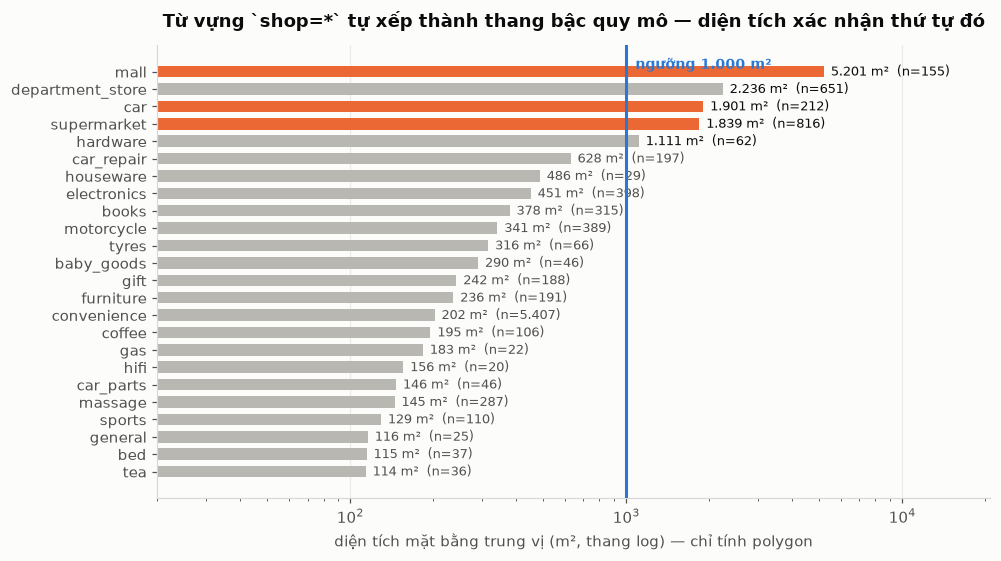

In [7]:
import matplotlib.pyplot as plt

# Bảng màu + rcParams kế thừa từ eda_chungcu (validator: CVD ΔE 9,2 · normal 24,0 → PASS).
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#b8b7b2"
INK, MUTED, BG = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": "#d9d8d4", "axes.grid": True, "grid.color": "#ebeae6",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "text.color": INK,
    "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})


def fmt(x, n=0):
    """Số kiểu Việt: dấu chấm ngăn nghìn."""
    return f"{x:,.{n}f}".translate(str.maketrans(",.", ".,"))


# 2A — QUÉT NGƯỠNG. Câu hỏi: lấy diện tích trung vị làm thước, cắt ở đâu thì tập "bậc lớn"
# ổn định? Ổn định nghĩa là: dịch ngưỡng một bậc mà tập không đổi thành phần đáng kể.
tm_shop = tm[tm["shop"].notna()]
bac_dt = tm_shop.groupby("shop").agg(
    n=("shop", "size"), dt=("area_m2", lambda s: s[s > 0].median()), poly=("is_area", "mean")
).dropna(subset=["dt"])
bac_dt = bac_dt[bac_dt["n"] >= 20].sort_values("dt", ascending=False)

print("quét ngưỡng diện tích trung vị → tập 'bậc LỚN' gồm những giá trị shop nào")
truoc = None
for T in [250, 500, 750, 1000, 1500, 2000, 3000]:
    tap = set(bac_dt[bac_dt["dt"] >= T].index)
    them = "" if truoc is None else f"  (bớt: {sorted(truoc - tap) or '—'})"
    n_poi = int(tm_shop["shop"].isin(tap).sum())
    print(f"  ≥ {fmt(T):>5} m²: {len(tap):2d} giá trị, {fmt(n_poi):>6} POI  {sorted(tap)}{them}")
    truoc = tap

# Ngưỡng chọn 1.000 m² — ĐẶT TAY, và đây là lý do: dưới mức đó tập nở ra bằng
# `car_repair`/`electronics`/`books` (cửa hàng phố, không phải điểm đến có bãi đỗ); trên
# 1.500 m² thì mất `supermarket`, tức mất đúng nhóm mà đề bài gọi tên. 1.000 m² ≈ một sàn
# bán hàng thật, và nó nằm trong khoảng mà tập không đổi thành phần cốt lõi.
DT_LON = 1_000

# CỔNG ĐỘ PHỦ — sửa lỗi gốc của vòng trước. Trung vị diện tích KHÔNG phải bằng chứng nếu
# nó tính trên một mẩu nhỏ của bậc: `mall` có 77% polygon (trung vị 5.201 m² là số đo thật),
# `department_store` có 2,5% (trung vị 2.236 m² là số đo của 16 dòng, áp cho 651). Cột `poly`
# đã được tính ngay trên kia và vòng trước không dùng nó làm điều kiện gì — đó là toàn bộ
# lỗ hổng. Đo lại bằng thước NGOÀI (bước 4C): nhóm `department_store` có lift trạm sạc 1,03
# (≈ nền đô thị) trong khi `mall` 3,12 ⇒ nó không hành xử như trung tâm thương mại.
DO_PHU_TOI_THIEU = 0.15
BAC_LON_DO = set(bac_dt[(bac_dt["dt"] >= DT_LON) & (bac_dt["poly"] >= DO_PHU_TOI_THIEU)].index)
# `wholesale`/`trade` có n < 20 nên không lọt vào `bac_dt`; giữ bằng ĐỊNH NGHĨA vì bản thân
# từ vựng đã nói quy mô. KHÔNG thêm tay `department_store` nữa — xem trên.
BAC_LON = BAC_LON_DO | {"wholesale", "trade"}
_rot = sorted(set(bac_dt[bac_dt["dt"] >= DT_LON].index) - BAC_LON_DO)
print()
for _k in _rot:
    print(f"  cổng độ phủ LOẠI {_k}: chỉ {bac_dt.loc[_k, 'poly']:.0%} polygon"
          f" (trung vị {fmt(bac_dt.loc[_k, 'dt'])} m² tính trên {int(bac_dt.loc[_k, 'poly'] * bac_dt.loc[_k, 'n'])} dòng)")
print(f"\nBẬC LỚN chốt lại ({len(BAC_LON)}): {sorted(BAC_LON)}")

fig, ax = plt.subplots(figsize=(9.2, 5.2))
b = bac_dt.head(24).sort_values("dt")
cols = [ORANGE if i in BAC_LON else GRAY for i in b.index]
ax.barh(b.index, b["dt"], color=cols, height=0.66)
ax.axvline(DT_LON, color=BLUE, linewidth=2, zorder=5)
ax.annotate(f"ngưỡng {fmt(DT_LON)} m²", (DT_LON, len(b) - 0.2), color=BLUE, fontsize=9,
            fontweight="bold", ha="left", va="top", xytext=(6, 0), textcoords="offset points")
for y, (v, n) in enumerate(zip(b["dt"], b["n"])):
    ax.text(v * 1.06, y, f"{fmt(v)} m²  (n={fmt(n)})", va="center", fontsize=8.5,
            color=INK if v >= DT_LON else MUTED)
ax.set_xscale("log")
ax.set_xlim(20, float(b["dt"].max()) * 4)
ax.grid(axis="y", visible=False)
ax.set_xlabel("diện tích mặt bằng trung vị (m², thang log) — chỉ tính polygon")
ax.set_title("Từ vựng `shop=*` tự xếp thành thang bậc quy mô — diện tích xác nhận thứ tự đó", pad=12)
fig.tight_layout()
plt.show()

In [8]:
# [DATA] sinh cột: brand_tier, brand_n, brand_dt
# 2B — THỪA KẾ THEO THƯƠNG HIỆU.
# Vấn đề: 53% lớp này là node, không có diện tích. Nhưng một thương hiệu bán lẻ có ĐỊNH DẠNG
# CỬA HÀNG thống nhất — WinMart luôn là siêu thị, WinMart+ luôn là cửa hàng tiện lợi. Nên
# quy mô học được từ vài điểm bán CÓ polygon của thương hiệu đó áp được cho mọi điểm bán còn lại.
#
# Điều kiện an toàn (thiếu là hỏng): thương hiệu phải có ≥ 3 điểm bán đo được diện tích, nếu
# không thì một polygon vẽ sai kéo cả chuỗi theo.
# Bẫy đã trả giá một vòng: học tier trên MỌI dòng có brand thì `Petrolimex` (sân cây xăng
# rộng 200–2.000 m²) được xếp bậc LỚN, rồi tấm khiên lấy đúng bậc đó che cho 4 trạm xăng
# sống sót qua luật "amenity lớp khác". Nên chỉ học từ dòng KHÔNG thuộc họ amenity ngoài lớp.
TOI_THIEU_DO = 3
_co_dt = tm["area_m2"] > 0
_bt = tm[tm["brand"].notna() & ~tm["amenity"].isin(AMENITY_NGOAI_LOP)].copy()
_bt["_dt"] = tm["area_m2"].where(_co_dt)
hoc = _bt.groupby("brand").agg(n=("brand", "size"), n_do=("_dt", "count"), dt=("_dt", "median"))
hoc = hoc[hoc["n_do"] >= TOI_THIEU_DO]
hoc["tier"] = np.where(hoc["dt"] >= DT_LON, "LON", "NHO")

print(f"thương hiệu học được định dạng: {len(hoc)} / {tm['brand'].nunique()} thương hiệu có mặt")
print(hoc.sort_values("n", ascending=False).head(18).round(0).to_string())

tm["brand_tier"] = tm["brand"].map(hoc["tier"])
tm["brand_n"] = tm["brand"].map(hoc["n"])
tm["brand_dt"] = tm["brand"].map(hoc["dt"])

# Thừa kế BỒI được bao nhiêu? Chỉ tính các dòng KHÔNG tự đo được diện tích.
node_tran = tm["area_m2"].isna() | tm["area_m2"].le(0)
boi = node_tran & tm["brand_tier"].notna()
print(f"\ndòng KHÔNG tự đo được diện tích: {node_tran.sum():,} ({node_tran.mean():.0%})")
print(f"  trong đó thừa kế được định dạng từ thương hiệu: {boi.sum():,}"
      f" ({boi.sum() / node_tran.sum():.1%} của nhóm mù)")
print(f"  → thừa kế xếp {int((boi & tm['brand_tier'].eq('LON')).sum()):,} node vào bậc LỚN"
      " mà nếu chỉ nhìn diện tích thì chúng vô hình")
print("\n  ví dụ node được thừa kế bậc LỚN:",
      tm.loc[boi & tm["brand_tier"].eq("LON"), "name"].dropna().head(6).tolist())

thương hiệu học được định dạng: 35 / 254 thương hiệu có mặt
                  n  n_do      dt tier
brand                                 
WinMart+       1070    13   125.0  NHO
PNJ             163     6   203.0  NHO
Circle K        160     9   110.0  NHO
WinMart          77    12  1670.0  LON
Honda            71    19   750.0  NHO
GS25             55     9   128.0  NHO
FamilyMart       50     9   145.0  NHO
Ministop         36     6   132.0  NHO
Bách Hóa XANH    32    10   339.0  NHO
VinFast          26     6   771.0  NHO
Toyota           19    13  2402.0  LON
Adidas           15     7   218.0  NHO
Big C            12     5  7636.0  LON
Yamaha           11     3   660.0  NHO
Vincom           11     7  8156.0  LON
Ford             10     6  2428.0  LON
Viettel Store    10     3   175.0  NHO
Hyundai           9     7  1826.0  LON

dòng KHÔNG tự đo được diện tích: 16,770 (83%)
  trong đó thừa kế được định dạng từ thương hiệu: 2,121 (12.6% của nhóm mù)
  → thừa kế xếp 103 node vào bậc LỚN 

In [9]:
# 2C — thử và BÁC một giả thuyết. Ghi kết quả ÂM lại là một phần của phương pháp: lớp lưu
# trú đã tốn một vòng để bác `n_tags`, lớp này bác giả thuyết dưới đây.
#
# Giả thuyết: "thương hiệu càng nhiều điểm bán thì mỗi điểm càng nhỏ" (chuỗi tiện lợi mở
# hàng nghìn cửa; đại siêu thị chỉ vài cái). Nghe rất hợp lý, và có một cặp chứng minh hoàn
# hảo: WinMart+ 1.070 điểm / 124 m² so với WinMart 77 điểm / 1.670 m².
_h = hoc[hoc["dt"] > 0]
r = np.corrcoef(np.log(_h["n"]), np.log(_h["dt"]))[0, 1]
print(f"tương quan log(số điểm bán) ~ log(diện tích trung vị), n = {len(_h)} thương hiệu: {r:+.3f}")
print("→ giả thuyết BỊ BÁC. Một cặp ví dụ đẹp không phải một quy luật.")
print("\nnhìn vào đuôi mới thấy vì sao:")
print(_h.sort_values("n", ascending=False).head(4).round(0).to_string())
print(_h.sort_values("dt", ascending=False).head(4).round(0).to_string())
print("\nCặp WinMart/WinMart+ đúng vì hai định dạng của CÙNG một công ty. So giữa các công ty"
      " khác nhau thì số điểm bán chỉ nói về tuổi và vốn của chuỗi, không nói gì về mỗi cửa hàng.")

tương quan log(số điểm bán) ~ log(diện tích trung vị), n = 35 thương hiệu: -0.055
→ giả thuyết BỊ BÁC. Một cặp ví dụ đẹp không phải một quy luật.

nhìn vào đuôi mới thấy vì sao:
             n  n_do      dt tier
brand                            
WinMart+  1070    13   125.0  NHO
PNJ        163     6   203.0  NHO
Circle K   160     9   110.0  NHO
WinMart     77    12  1670.0  LON
                         n  n_do       dt tier
brand                                         
Lotte Department Store   8     3  23022.0  LON
Vincom                  11     7   8156.0  LON
Big C                   12     5   7636.0  LON
Kia                      6     3   2587.0  LON

Cặp WinMart/WinMart+ đúng vì hai định dạng của CÙNG một công ty. So giữa các công ty khác nhau thì số điểm bán chỉ nói về tuổi và vốn của chuỗi, không nói gì về mỗi cửa hàng.


### 2D — ĐỊNH DẠNG CHUỖI: thang đo BẤT ĐỐI XỨNG

2A hỏi "bậc `shop=*` cắt ở đâu" và trả lời bằng diện tích trung vị. Cell này vạch ra
**lỗ hổng của chính phép đo đó**, rồi sửa bằng một thang bất đối xứng.

Lỗ hổng: trung vị được tin như nhau ở mọi bậc, bất kể **bao nhiêu phần trăm** của bậc đó
đo được. `mall` có 77% polygon — trung vị 5.201 m² là số đo thật. `department_store` có
**2,5%** polygon — trung vị 2.236 m² là số đo của 16 dòng, áp cho 651. Cột `poly` đã được
tính ngay trong `bac_dt` ở 2A và không được dùng làm điều kiện gì.

Thang bất đối xứng, theo đúng logic bằng chứng chứ không theo tính đối xứng hình thức:

- **Định dạng LỚN** (`mall`, thương hiệu TTTM/đại siêu thị) — tiên nghiệm mạnh, và
  **thiếu polygon KHÔNG phải bằng chứng chống**: một TTTM bị map thành node vẫn là TTTM.
  Không đòi diện tích.
- **Định dạng NHỎ** (chuỗi tiện lợi, minimart) — tiên nghiệm là NHỎ, và tiên nghiệm này
  chắc hơn bất kỳ tag nào: định dạng cửa hàng là quyết định của doanh nghiệp, không phải
  của người map. Chỉ giữ khi **tự đo được** diện tích ≥ ngưỡng.

Bất đối xứng vì hai lớp sai khác nhau về giá: bỏ sót một TTTM là mất một điểm đến thật;
giữ nhầm một Circle K là bơm một điểm rác vào nhóm mà mọi thống kê hạ nguồn tin nhất.


In [10]:
# [DATA] sinh cột: la_chuoi_nho, la_chuoi_lon, dinh_dang_nho
# 2D — vì sao 2A hụt: trung vị KHÔNG kèm ĐỘ PHỦ thì không phải bằng chứng.
# Chuỗi bán lẻ là chỗ kiểm chứng tốt nhất vì định dạng của chúng đã biết TỪ BÊN NGOÀI dữ
# liệu (Circle K là tiện lợi, Co.opmart là siêu thị) — tức có sẵn nhãn thật để đối chiếu.
CHUOI_NHO_RX = (
    r"circle ?k|\bgs ?25\b|family ?mart|mini ?stop|ministop|7[- ]?eleven|b'?s ?mart"
    r"|shop ?& ?go|\bcheers\b|vinshop|winmart ?\+|vinmart ?\+|winmart plus"
    r"|bach hoa xanh|\bbhx\b|co\.?op ?food|satra ?food"
)
# Bách hoá tổng hợp CÓ THẬT + hậu tố toà nhà: hai danh sách mà cổng độ phủ cần để không
# giết oan (Takashimaya, Parkson, Muji là node nhưng là TTTM thật) và để không nhận nhầm
# ("Plaza"/"Tower" trong tiếng Việt là hậu tố TOÀ NHÀ, không phải loại hình).
BACH_HOA_THAT_RX = (r"takashimaya|\bparkson\b|lotte department|diamond plaza|trang tien"
                    r"|\bmuji\b|union square|\bvincom\b|\baeon\b|robins|\bnowzone\b")
TOA_NHA_RX = r"toa nha|\btower\b|van phong|\boffice\b|tiec cuoi|hoi nghi|can ho|chung cu"
DINH_DANG_NHO_RX = (r"tap hoa|tien loi|\bmini\b|mini ?(?:mart|stop|shop|market)"
                    r"|\bkiosk\b|ki ?-?ot|tu chon")
CHUOI_LON_RX = (
    r"co\.?op ?mart|co\.?op ?xtra|\bbig ?c\b|(?<!&)\bgo!|mega market|\bmm mega\b"
    r"|\bemart\b|lotte ?mart|lotte department|\baeon\b|\bvincom\b|\bparkson\b"
    r"|crescent mall|vivo ?city|trang tien plaza"
)
# `winmart` trần KHÔNG vào danh sách lớn: đo ở dưới cho thấy chuỗi này LƯỠNG ĐỈNH — tên
# trong OSM không phân biệt được WinMart (siêu thị) với WinMart+ (tiện lợi) một cách đáng
# tin, nên nó phải được xét theo TỪNG ĐIỂM BÁN, không theo thương hiệu.

_ct = (tm["brand"].fillna("") + " " + tm["operator"].fillna("") + " " + tm["name_norm"]).map(strip_accents)
tm["la_chuoi_nho"] = _ct.str.contains(CHUOI_NHO_RX, regex=True, na=False)
tm["la_chuoi_lon"] = _ct.str.contains(CHUOI_LON_RX, regex=True, na=False)

CHUOI = [
    ("Circle K", r"circle ?k", "NHO"), ("GS25", r"\bgs ?25\b", "NHO"),
    ("FamilyMart", r"family ?mart", "NHO"), ("Ministop", r"mini ?stop", "NHO"),
    ("7-Eleven", r"7[- ]?eleven", "NHO"), ("Shop&Go", r"shop ?& ?go", "NHO"),
    ("WinMart+", r"winmart ?\+|vinmart ?\+", "NHO"), ("Bách hóa Xanh", r"bach hoa xanh", "NHO"),
    ("Co.op Food", r"co\.?op ?food", "NHO"), ("SatraFood", r"satra ?food", "NHO"),
    ("WinMart", r"\bwinmart\b(?! ?\+)|\bvinmart\b(?! ?\+)", "?"),
    ("Co.opmart", r"co\.?op ?mart", "LON"), ("Big C", r"\bbig ?c\b", "LON"),
    ("GO!", r"(?<!&)\bgo!", "LON"), ("Lotte Mart", r"lotte ?mart", "LON"),
    ("AEON", r"\baeon\b", "LON"), ("Emart", r"\bemart\b", "LON"),
    ("MM Mega Market", r"mega market", "LON"), ("Vincom", r"\bvincom\b", "LON"),
]
rows = []
for ten, rx, lop in CHUOI:
    d = tm[_ct.str.contains(rx, regex=True, na=False)]
    dd = d[d["area_m2"] > 0]
    if len(d) < 5:
        continue
    rows.append(dict(chuoi=ten, lop=lop, n=len(d), n_do=len(dd),
                     phu=len(dd) / len(d) if len(d) else 0,
                     p10=dd["area_m2"].quantile(.10) if len(dd) else np.nan,
                     tv=dd["area_m2"].median() if len(dd) else np.nan,
                     p90=dd["area_m2"].quantile(.90) if len(dd) else np.nan))
ch = pd.DataFrame(rows)
print("định dạng chuỗi — nhãn thật biết TỪ NGOÀI dữ liệu, dùng để kiểm phép đo diện tích:")
print(ch.assign(phu=lambda d: (100 * d["phu"]).round(0)).round(0).to_string(index=False))

_nho = ch[ch["lop"].eq("NHO") & ch["p90"].notna()]
_lon = ch[ch["lop"].eq("LON") & ch["p10"].notna()]
KHE_D, KHE_T = float(_nho["p90"].max()), float(_lon["p10"].min())
print(f"\nKHE PHÂN TÁCH: chuỗi nhỏ cao nhất (p90) = {fmt(KHE_D)} m²"
      f"  ·  chuỗi lớn thấp nhất (p10) = {fmt(KHE_T)} m²")
print(f"  ngưỡng DT_LON = {fmt(DT_LON)} m² của 2A nằm TRONG khe → xác nhận ngưỡng đó, "
      "bằng một phép đo độc lập với phép đã chọn ra nó")


định dạng chuỗi — nhãn thật biết TỪ NGOÀI dữ liệu, dùng để kiểm phép đo diện tích:
         chuoi lop    n  n_do  phu     p10      tv     p90
      Circle K NHO  202    13  6.0    83.0   122.0   313.0
          GS25 NHO   71     9 13.0    68.0   128.0   362.0
    FamilyMart NHO   74    13 18.0    80.0   150.0   203.0
      Ministop NHO   43     6 14.0   100.0   132.0   227.0
      7-Eleven NHO   46     2  4.0    57.0    66.0    75.0
       Shop&Go NHO   12     0  0.0     NaN     NaN     NaN
      WinMart+ NHO 1128    25  2.0    52.0   142.0   257.0
 Bách hóa Xanh NHO  177    65 37.0   188.0   405.0   645.0
    Co.op Food NHO   24     2  8.0   328.0   329.0   331.0
     SatraFood NHO   15     1  7.0   187.0   187.0   187.0
       WinMart   ?  121    23 19.0   153.0   460.0  2983.0
     Co.opmart LON  120    28 23.0  1665.0  3371.0  6181.0
         Big C LON   42     8 19.0  2490.0  6370.0 24239.0
           GO! LON   22    10 45.0  5381.0  7168.0  9648.0
    Lotte Mart LON   23     6 26

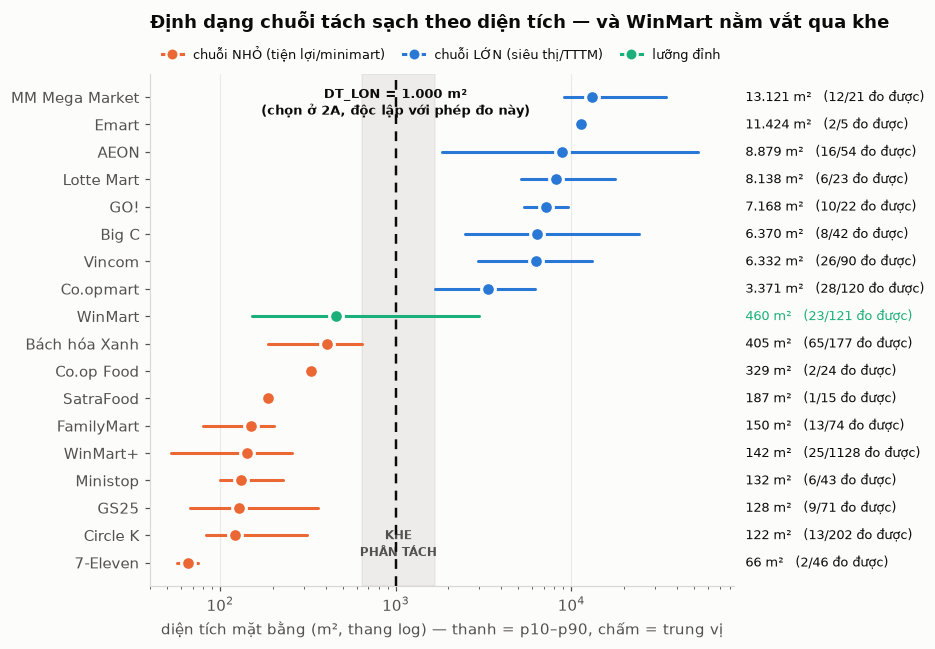

Đọc biểu đồ:
  • Hai lớp KHÔNG chồng lấn — khe 645–1.665 m² rỗng hoàn toàn.
    Diện tích LÀ thước đúng để phân định dạng, khi nó đo được.
  • WinMart (xanh lá) vắt qua khe: p10 153 → p90 2.983 m². Một thương hiệu, hai định dạng.
    ⇒ tier theo THƯƠNG HIỆU sai với chuỗi lưỡng đỉnh; phải xét TỪNG ĐIỂM BÁN.
  • Cột 'đo được' là chỗ chết người: chuỗi nhỏ chỉ 8% có diện tích ⇒ với đa số, diện tích KHÔNG trả lời được gì.


In [11]:
# BIỂU ĐỒ 1 — bằng chứng cho thang bất đối xứng: hai lớp chuỗi KHÔNG chồng lấn.
# Mỗi chuỗi một thanh p10–p90; nhãn thật (NHO/LON) quyết định màu. Nếu diện tích là thước
# đúng thì hai màu phải tách rời — và khe giữa chúng là nơi đặt ngưỡng.
_p = ch[ch["tv"].notna()].sort_values("tv")
fig, ax = plt.subplots(figsize=(9.6, 6.0))
C = {"NHO": ORANGE, "LON": BLUE, "?": GREEN}
for y, (_, r) in enumerate(_p.iterrows()):
    c = C[r["lop"]]
    ax.plot([r["p10"], r["p90"]], [y, y], color=c, linewidth=2, solid_capstyle="round", zorder=3)
    ax.plot([r["tv"]], [y], "o", color=c, markersize=9, markeredgecolor=BG,
            markeredgewidth=2, zorder=4)
    # nhãn xếp thành CỘT cố định ngoài vùng vẽ — trong vùng vẽ chúng đè lên dải khe.
    ax.text(1.02, y, f'{fmt(r["tv"])} m²   ({int(r["n_do"])}/{int(r["n"])} đo được)',
            transform=ax.get_yaxis_transform(), clip_on=False,
            va="center", fontsize=8.5, color=INK if r["lop"] != "?" else GREEN)
ax.axvspan(KHE_D, KHE_T, color=GRAY, alpha=0.22, zorder=0)
ax.axvline(DT_LON, color=INK, linewidth=1.6, linestyle=(0, (4, 3)), zorder=5)
ax.annotate(f"DT_LON = {fmt(DT_LON)} m²\n(chọn ở 2A, độc lập với phép đo này)",
            (DT_LON, len(_p) - 0.4), color=INK, fontsize=8.5, fontweight="bold",
            ha="center", va="top", xytext=(0, -4), textcoords="offset points")
ax.annotate("KHE\nPHÂN TÁCH", ((KHE_D * KHE_T) ** 0.5, 0.15), color=MUTED, fontsize=8,
            ha="center", va="bottom", fontweight="bold", linespacing=1.3)
ax.set_yticks(range(len(_p))); ax.set_yticklabels(_p["chuoi"])
ax.set_xscale("log"); ax.set_xlim(40, float(_p["p90"].max()) * 1.6)
ax.grid(axis="y", visible=False)
ax.set_xlabel("diện tích mặt bằng (m², thang log) — thanh = p10–p90, chấm = trung vị")
ax.set_title("Định dạng chuỗi tách sạch theo diện tích — và WinMart nằm vắt qua khe", pad=30, loc="left")
ax.legend(handles=[plt.Line2D([], [], color=C[k], lw=2, marker="o", markersize=8,
                              markeredgecolor=BG, markeredgewidth=1.5) for k in ["NHO", "LON", "?"]],
          labels=["chuỗi NHỎ (tiện lợi/minimart)", "chuỗi LỚN (siêu thị/TTTM)", "lưỡng đỉnh"],
          ncol=3, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False, fontsize=8.5,
          handlelength=1.6, columnspacing=1.4)
fig.tight_layout()
fig.subplots_adjust(right=0.70)
plt.show()

print("Đọc biểu đồ:")
print(f"  • Hai lớp KHÔNG chồng lấn — khe {fmt(KHE_D)}–{fmt(KHE_T)} m² rỗng hoàn toàn.")
print(f"    Diện tích LÀ thước đúng để phân định dạng, khi nó đo được.")
print(f"  • WinMart (xanh lá) vắt qua khe: p10 {fmt(_p.loc[_p['chuoi'].eq('WinMart'),'p10'].iloc[0])}"
      f" → p90 {fmt(_p.loc[_p['chuoi'].eq('WinMart'),'p90'].iloc[0])} m². Một thương hiệu, hai định dạng."
      "\n    ⇒ tier theo THƯƠNG HIỆU sai với chuỗi lưỡng đỉnh; phải xét TỪNG ĐIỂM BÁN.")
print(f"  • Cột 'đo được' là chỗ chết người: chuỗi nhỏ chỉ "
      f"{100 * ch.loc[ch['lop'].eq('NHO'), 'n_do'].sum() / ch.loc[ch['lop'].eq('NHO'), 'n'].sum():.0f}%"
      " có diện tích ⇒ với đa số, diện tích KHÔNG trả lời được gì.")


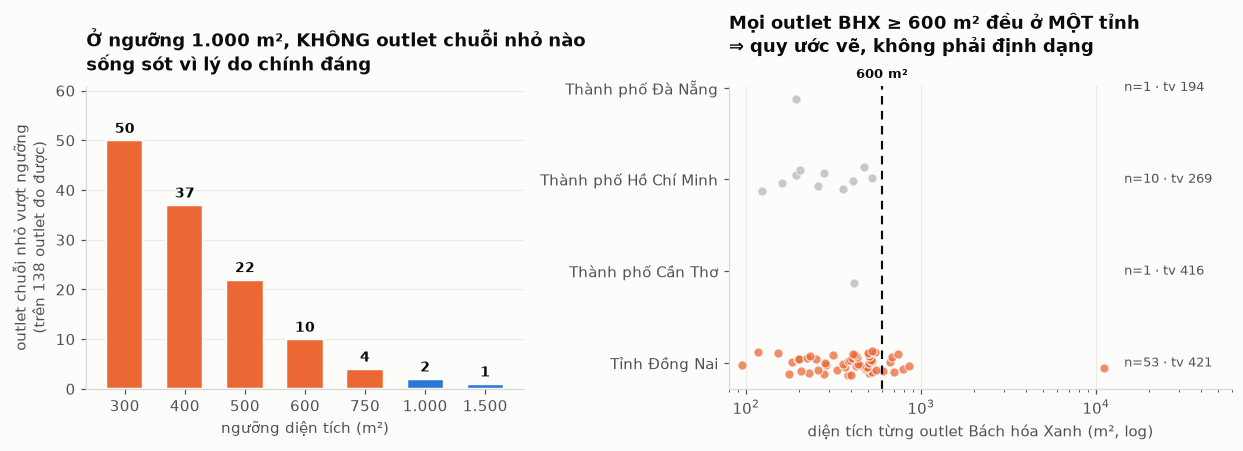

soi TỪNG outlet chuỗi nhỏ ≥ 600 m² (10 dòng) — có cái nào là cửa hàng lớn thật không:
     11,128 m²  Kho Bách hóa Xanh Thành phố Biên Hoà                   Tỉnh Đồng Nai
      1,173 m²  Lẩu dê Vườn Xoài 15                                    Tỉnh Đồng Nai
        854 m²  Bách hóa Xanh                                          Tỉnh Đồng Nai
        786 m²  Bách hóa Xanh                                          Tỉnh Đồng Nai
        743 m²  Bách hóa Xanh                                          Tỉnh Đồng Nai
        706 m²  Bách hóa Xanh                                          Tỉnh Đồng Nai
        683 m²  Bách hóa Xanh                                          Tỉnh Đồng Nai
        670 m²  Bách hóa Xanh                                          Tỉnh Đồng Nai
        631 m²  GS25                                                   Thành phố Cần Thơ
        606 m²  Bách hóa Xanh                                          Tỉnh Đồng Nai

  → hai dòng đầu là KHO phân phối và một quán lẩu mang bran

In [12]:
# BIỂU ĐỒ 2 — hai chốt chặn mà luật "trên ngưỡng thì giữ" bắt buộc phải có.
# Trái : quét ngưỡng — bao nhiêu outlet chuỗi nhỏ vượt, và chúng có THẬT không.
# Phải : Bách hóa Xanh theo tỉnh — bằng chứng rằng diện tích lớn ở chuỗi nhỏ phần lớn là
#        QUY ƯỚC VẼ của một tỉnh, không phải outlet lớn thật.
_nd = tm[tm["la_chuoi_nho"] & (tm["area_m2"] > 0)]
Ts = [300, 400, 500, 600, 750, 1000, 1500]
so = [int((_nd["area_m2"] >= T).sum()) for T in Ts]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.2), gridspec_kw={"width_ratios": [1, 1.15]})

a1.bar([str(fmt(t)) for t in Ts], so, color=[ORANGE if t < DT_LON else BLUE for t in Ts],
       width=0.62, edgecolor=BG, linewidth=1.6)
for x, v in enumerate(so):
    a1.text(x, v + max(so) * 0.03, str(v), ha="center", fontsize=9, color=INK, fontweight="bold")
a1.set_ylim(0, max(so) * 1.22)
a1.grid(axis="x", visible=False)
a1.set_xlabel("ngưỡng diện tích (m²)")
a1.set_ylabel(f"outlet chuỗi nhỏ vượt ngưỡng\n(trên {len(_nd)} outlet đo được)")
a1.set_title("Ở ngưỡng 1.000 m², KHÔNG outlet chuỗi nhỏ nào\nsống sót vì lý do chính đáng", loc="left", pad=10)

bx = tm[tm["name_norm"].map(strip_accents).str.contains("bach hoa xanh", na=False) & (tm["area_m2"] > 0)]
_o = bx.groupby("province_name")["area_m2"].median().sort_values(ascending=False)
_o = _o[bx.groupby("province_name").size().reindex(_o.index) >= 1]
for y, tinh in enumerate(_o.index):
    v = bx.loc[bx["province_name"].eq(tinh), "area_m2"].values
    c = ORANGE if len(v) >= 20 else GRAY
    a2.plot(v, np.full(len(v), y) + np.linspace(-.13, .13, len(v)), "o", color=c,
            markersize=6, alpha=.75, markeredgecolor=BG, markeredgewidth=.8)
    a2.text(1.45e4, y, f"n={len(v)} · tv {fmt(np.median(v))}", va="center", fontsize=8.5, color=MUTED)
a2.axvline(600, color=INK, linewidth=1.4, linestyle=(0, (4, 3)))
a2.annotate("600 m²", (600, 1.0), xycoords=("data", "axes fraction"), fontsize=8.5,
            color=INK, ha="center", va="bottom", xytext=(0, 3), textcoords="offset points",
            fontweight="bold")
a2.set_yticks(range(len(_o))); a2.set_yticklabels(_o.index)
a2.set_xscale("log"); a2.set_xlim(80, 6e4); a2.grid(axis="y", visible=False)
a2.set_xlabel("diện tích từng outlet Bách hóa Xanh (m², log)")
a2.set_title("Mọi outlet BHX ≥ 600 m² đều ở MỘT tỉnh\n⇒ quy ước vẽ, không phải định dạng", loc="left", pad=22)
fig.tight_layout()
plt.show()

_big = _nd[_nd["area_m2"] >= 600].sort_values("area_m2", ascending=False)
print(f"soi TỪNG outlet chuỗi nhỏ ≥ 600 m² ({len(_big)} dòng) — có cái nào là cửa hàng lớn thật không:")
for _, r in _big.head(12).iterrows():
    print(f"  {r['area_m2']:9,.0f} m²  {str(r['name'])[:52]:54s} {r['province_name']}")
print("\n  → hai dòng đầu là KHO phân phối và một quán lẩu mang brand=Circle K (rác trường brand).")
print("  → phần còn lại là Bách hóa Xanh Đồng Nai: polygon vẽ cả thửa/nhà, không phải sàn bán.")
print("  ⇒ Ở nhóm chuỗi nhỏ, diện tích LỚN là dấu hiệu của LỖI MAP nhiều hơn là outlet lớn.")
print("    Luật 'trên ngưỡng thì giữ' vì thế phải kèm hai chốt: loại KHO, và đòi ngưỡng ở"
      f" mức {fmt(DT_LON)} m² (khe phân tách) chứ không hạ xuống 600.")

# LUẬT: định dạng nhỏ — mặc định LOẠI, thoát ra chỉ bằng diện tích TỰ ĐO của chính điểm bán.
LA_KHO = (
    tm["name_norm"].map(strip_accents).str.contains(r"\bkho\b|kho hang|warehouse|trung tam phan phoi", na=False)
    | tm["building"].eq("warehouse") | tm["landuse"].eq("industrial")
)
DU_LON_TU_DO = (tm["area_m2"].fillna(0) >= DT_LON) & ~LA_KHO
# Hai nhánh: (a) thuộc chuỗi nhỏ đã biết, (b) TÊN tự khai định dạng nhỏ. Nhánh (b) đo ra
# hiệu quả cao nhất trong cả bộ vá — nhóm nó cắt có lift trạm 0,41 (rác gần như thuần).
TEN_TU_KHAI_NHO = tm["name_norm"].str.contains(DINH_DANG_NHO_RX, regex=True, na=False)
tm["dinh_dang_nho"] = (
    (tm["la_chuoi_nho"] | (TEN_TU_KHAI_NHO & tm["brand_tier"].ne("LON")))
    & ~DU_LON_TU_DO & ~tm["la_chuoi_lon"]
)
print(f"  nhánh (b) TÊN tự khai định dạng nhỏ: {int(TEN_TU_KHAI_NHO.sum()):,} dòng")
print(f"\n⇒ dinh_dang_nho = {int(tm['dinh_dang_nho'].sum()):,} dòng bị đánh dấu NHỎ"
      f"  (thoát nhờ diện tích tự đo: {int((tm['la_chuoi_nho'] & DU_LON_TU_DO).sum())})")


### REVIEW — chốt thang quy mô

**Soi gì:** bảng bậc `shop=*` × diện tích trung vị, quét 7 ngưỡng, 35 thương hiệu học được
định dạng, và một giả thuyết bị bác.

**Tìm được:**
- **Bậc `shop=*` là thang bậc THẬT.** Hai đại lượng độc lập — từ vựng tag (người map chọn)
  và diện tích (hình vẽ quyết định) — xếp cùng một thứ tự: `mall` → `department_store` →
  `supermarket` → … → `convenience`. Lớp lưu trú không có gì tương đương.
- **Ngưỡng 1.000 m² là chỗ tập ổn định.** Dưới nó tập nở ra bằng cửa hàng phố
  (`car_repair`, `electronics`, `books`); trên 1.500 m² thì mất `supermarket` — mất đúng
  nhóm đề bài gọi tên. Vẫn là ngưỡng **đặt tay**, ghi rõ như vậy.
- **Thừa kế theo thương hiệu là cơ chế đắt giá nhất của lớp này**: nó nhìn thấy quy mô của
  những node mà mọi trục hình học đều mù.
- **Một giả thuyết bị bác** (số điểm bán ~ quy mô, r ≈ 0). Ghi lại để không ai thử lại.

**Quyết định:** `hang_tm` (loại hình) và `quy_mo_tm` (bậc lớn/nhỏ, kèm `quy_mo_nguon`
ghi bằng chứng đến từ diện tích tự đo hay từ thừa kế thương hiệu).

→ TỰ PHÊ DUYỆT, đi tiếp.

## Bước 3 — precision: mỗi luật một cell

Nguyên tắc bất biến: **tag mô tả VẬT THỂ, tên chỉ là MỐC THAM CHIẾU**.

Bài học vừa trả giá ở lớp lưu trú, áp thẳng vào đây: **regex TUYỂN và regex MIỄN TRỪ là
hai danh sách khác nhau**. Tấm khiên của lớp này là `co_tag_ban_le_lon` — dựa trên TAG bậc
lớn, không dựa trên tên, vì "siêu thị" trong tên được gắn cho cả cửa hàng 40 m².

In [13]:
candidates = tm.copy()
remaining = candidates.copy()
remaining["mixed_use"] = False
removed_parts = []


def co_tag_ban_le_lon(df):
    """Bằng chứng bán lẻ QUY MÔ LỚN — tag hoặc thừa kế thương hiệu, KHÔNG phải tên."""
    return (
        df["shop"].isin(BAC_LON)
        | df["amenity"].eq("marketplace")
        # Loại trừ CHỈ áp cho nhánh thừa kế thương hiệu, không áp cho cả tấm khiên: đặt
        # `& ~ngoài_lớp` ra ngoài dấu ngoặc thì khiên chết hẳn (mọi luật dùng khiên đều bắt
        # theo đúng họ amenity đó ⇒ `tha` không bao giờ khớp). Cái cần chặn là `Petrolimex`
        # học ra bậc LỚN từ sân cây xăng rộng, không phải chặn `shop=mall`.
        | (df["brand_tier"].eq("LON") & ~df["amenity"].isin(AMENITY_NGOAI_LOP))
    )
    # ĐỊNH DẠNG NHỎ có quyền PHỦ QUYẾT tấm khiên (2D). Trước vòng này `brand_tier=NHO` chỉ
    # được dùng để THÊM vào bậc lớn, chưa bao giờ để loại ra — đó là lý do Bách hoá Xanh
    # 308 m² đi thẳng vào nhãn siêu thị.
    k &= ~df["dinh_dang_nho"]
    # CỨU NGƯỢC: cổng độ phủ giết cả bậc `department_store`, trong đó có bách hoá tổng hợp
    # THẬT (Takashimaya, Parkson, Muji) và chợ mang tag đó. Đo tay 11/11 dòng được cứu đều
    # đúng ⇒ trả khiên lại khi có bằng chứng riêng.
    k |= (
        df["shop"].eq("department_store")
        & (
            (df["is_area"].eq(True) & df["area_m2"].fillna(0).ge(DT_LON))
            | df["name_norm"].str.contains(BACH_HOA_THAT_RX, regex=True, na=False)
            | df["name_dau"].fillna("").str.contains(r"\bchợ\b", na=False)
        )
    )
    return k


def drop_rule(cond, rule, n=6, tha_hon_hop=False):
    """Xoá khỏi `remaining`, ghi `removed_parts`, in bằng chứng ngay tại chỗ.

    `tha_hon_hop=True`: một TTTM có nhà hàng, rạp phim, ngân hàng ở bên trong — nếu POI mang
    ĐỒNG THỜI tag bán lẻ bậc lớn và tag chức năng khác thì đó là MỘT toà trung tâm thương mại
    chứ không phải hai vật thể ⇒ GIỮ, cắm cờ `mixed_use`.
    """
    global remaining
    m = cond.reindex(remaining.index, fill_value=False)
    if tha_hon_hop:
        tha = m & co_tag_ban_le_lon(remaining)
        if tha.any():
            remaining.loc[tha, "mixed_use"] = True
            print(f"  ⊙ {tha.sum()} dòng có tag bán lẻ BẬC LỚN → GIỮ, cờ mixed_use:",
                  remaining.loc[tha, "name"].dropna().head(5).tolist())
            m = m & ~tha
    hit = remaining[m]
    print(f"{rule}: xoá {len(hit):,}  →  còn lại {len(remaining) - len(hit):,}")
    print("  mẫu :", hit["name"].dropna().head(n).tolist())
    conflict = hit[co_tag_ban_le_lon(hit)]
    if len(conflict):
        print(f"  ⚠ {len(conflict)} dòng mang tag bán lẻ bậc lớn:", conflict["name"].dropna().head(8).tolist())
    removed_parts.append(hit.assign(drop_reason=rule))
    remaining = remaining[~m]


print(f"vào bước 3: {len(remaining):,} dòng")

vào bước 3: 20,287 dòng


In [14]:
# LUẬT 1 — hạ tầng đường. Luật số 1 của cả ba lớp trước, và vẫn ăn nhiều nhất: tên trạm buýt
# lấy chợ / siêu thị làm mốc ("Trạm Xe Bus Co.op Mart Nguyễn Văn Linh", "Chợ Mơ - 459D Bạch Mai").
INFRA = (
    remaining["highway"].notna()
    | remaining["public_transport"].notna()
    | remaining["railway"].notna()
    | remaining["aeroway"].notna()
    # Bốn cột trên chỉ bắt tag hạ tầng. "Ga Chợ Tía" mang `building=train_station` và lọt
    # qua — nhà ga lấy tên chợ làm mốc, đúng họ với LUẬT 1 nhưng ở một cột khác.
    # Neo biên `\b` là BẮT BUỘC: `nha tro` không neo thì khớp bên trong "nhà TRỒng".
    | remaining["building"].isin(["train_station", "transportation", "bus_station"])
    | remaining["name_norm"].str.contains(
        r"^ga |\bnha ga\b|\bben xe\b|\bphong tro\b|\bnha tro\b", na=False)
)
print("tên có 'chợ' mà dính luật này:",
      int((INFRA & remaining["name_dau"].str.contains(r"\bchợ\b", na=False)).sum()))
print()
drop_rule(INFRA, "HA_TANG_DUONG")

tên có 'chợ' mà dính luật này: 498

HA_TANG_DUONG: xoá 764  →  còn lại 19,523
  mẫu : ['Số 10 Trần Phú - Siêu thị Việt Long', 'Chợ Mơ - 459D Bạch Mai', 'Đối diện Chợ Láng Hạ B - 564 đường Láng', 'Siêu thị Dos Mark', 'Chợ Thượng Đình - 224 Nguyễn Trãi', 'Đối diện Sun Plaza - Nguyễn Khoái']
  ⚠ 1 dòng mang tag bán lẻ bậc lớn: []


In [15]:
# LUẬT 2 — họ amenity thuộc LỚP KHÁC. Không phải "không phải POI", mà là "không phải lớp này":
# cây xăng → transit · ngân hàng/bưu điện → dịch vụ công · quán ăn → ăn uống · nhà thuốc → y tế.
# `tha_hon_hop` là bắt buộc: một TTTM mang thêm `amenity=cinema` vẫn là TTTM.
NGOAI_LOP = remaining["amenity"].isin(AMENITY_NGOAI_LOP)
print("phân bố amenity bị bắt:", remaining.loc[NGOAI_LOP, "amenity"].value_counts().head(8).to_dict())
print()
drop_rule(NGOAI_LOP, "AMENITY_LOP_KHAC", tha_hon_hop=True)

# LUẬT 2b — amenity của lớp ĐÃ/SẼ bóc, lọt vào qua TÊN. `AMENITY_NGOAI_LOP` ở bước 1 chỉ
# liệt kê họ hay lẫn với bán lẻ (xăng, ngân hàng, quán ăn). Nhóm dưới đây lọt bằng đường
# khác: chúng lấy tên CHỢ làm mốc địa chỉ — "Tiểu Học Long Hoà- sau Chợ Long Hoà",
# "Tu viện Mến Thánh Giá Chợ Quán", "Ban quản lý chợ Long Biên".
# Đo bằng thước ngoài trước khi xoá: cả nhóm có lift trạm = 0,00 (không một dòng nào gần
# trạm) và 12/12 soi tay đều sai ⇒ xoá. `tha_hon_hop` để một TTTM có rạp/phòng khám bên
# trong vẫn được giữ.
AMENITY_LOP_DA_BOC = [
    "school", "kindergarten", "college", "university", "driving_school", "childcare",
    "police", "fire_station", "townhall", "courthouse", "prison", "embassy",
    "place_of_worship", "clinic", "hospital", "doctors", "dentist",
    "library", "community_centre", "social_facility", "public_building",
    # ── RẠP PHIM / NHÀ HÁT (thẩm định 2026-08-09) ──
    # `amenity=cinema` là nguyên liệu của lớp THAM QUAN (lớp 5) — chính `TQ_TAG` khai
    # nó. Lớp này chạy ở vị trí 3, nên giữ lại là CƯỚP DÒNG của lớp sau, đúng họ lỗi
    # `co_wiki` đã vá ở thamquan. Đo được 5 dòng ("Rạp Phim CGV CT Plaza", "CGV Vincom
    # Imperia", "Aeon Beta Cinema") đang mang nhãn TTTM — sai cả LỚP lẫn NHÃN.
    # `tha_hon_hop=True` giữ nguyên "Lotte Department Store" (rạp BÊN TRONG một TTTM
    # thật): nó có bằng chứng bán lẻ bậc lớn nên đi qua cửa tha, không rơi ở đây.
    "cinema", "theatre", "arts_centre",
]
drop_rule(remaining["amenity"].isin(AMENITY_LOP_DA_BOC), "AMENITY_LOP_DA_BOC", tha_hon_hop=True)


phân bố amenity bị bắt: {'charging_station': 252, 'vending_machine': 246, 'fuel': 66, 'cafe': 55, 'restaurant': 46, 'pharmacy': 16, 'parking': 9, 'fast_food': 7}

  ⊙ 3 dòng có tag bán lẻ BẬC LỚN → GIỮ, cờ mixed_use: ['Pizza Hut', 'Nhà đậu xe Aeon Mall Tân Phú Celadon;Commercial_AEONMallTanPhu Storie 4']
AMENITY_LOP_KHAC: xoá 707  →  còn lại 18,816
  mẫu : ['Cửa Hàng Xăng Dầu Satra', 'Máy Bán Nước Tự Động - Cty Máy Bán Hàng Tự Động Minh Lâm', 'Trung Tâm sửa chữa xe máy', 'PV Oil', 'Petec', 'Máy Bán Nước Tự Động - Cty Máy Bán Hàng Tự Động Minh Lâm']
  ⊙ 1 dòng có tag bán lẻ BẬC LỚN → GIỮ, cờ mixed_use: ['Lotte Department Store']
AMENITY_LOP_DA_BOC: xoá 26  →  còn lại 18,790
  mẫu : ['trung tâm thương mại vung tàu', 'Rạp Phim CGV CT Plaza', 'THọc-Tiểu Học Bến Súc-DT744- Chợ- Thanh Tuyền-TT.Dầu Tiếng-Bình Dương-', 'THọc-Phổ Thông Thanh Tuyền-DT744- Chợ- Thanh Tuyền-TT.Dầu Tiếng-Bình Dương-', 'THọc-Tiểu Học Long Hoà- sau Chợ Long Hoà-Ấp Long Điền- Long Hoà- Dầu Tiếng- Bình Dương-', 'CGV Vi

In [16]:
# LUẬT 3 — DỊCH VỤ, không phải BÁN HÀNG. `shop=hairdresser|massage|laundry|tattoo` là tiệm
# dịch vụ: khách ở lâu nhưng mặt bằng 60–80 m², không có bãi đỗ, không phải điểm đến.
# Tách drop_reason riêng khỏi BAN_LE_NHO vì lý do loại khác nhau: nhóm này sai LOẠI HÌNH,
# nhóm kia đúng loại hình nhưng sai QUY MÔ.
SHOP_DICH_VU = remaining["shop"].isin(
    ["hairdresser", "beauty", "massage", "laundry", "dry_cleaning", "tattoo", "copyshop",
     "travel_agency", "funeral_directors", "estate_agent", "insurance", "money_lender",
     "pawnbroker", "ticket", "photo", "tailor", "shoe_repair", "car_repair",
     "motorcycle_repair", "bicycle_repair", "repair", "locksmith", "vacant", "storage_rental"]
)
print()
drop_rule(SHOP_DICH_VU, "DICH_VU_KHONG_BAN_LE")


DICH_VU_KHONG_BAN_LE: xoá 2,451  →  còn lại 16,339
  mẫu : ['Ticket', 'Đại Lý Bán Vé Máy Bay Việt Nam Airlines', 'Thai Express', 'Thời Trang Tóc Đình Khải', 'Du Lịch Hùng Vỹ', 'Du Lịch Miền Nam']
  ⚠ 6 dòng mang tag bán lẻ bậc lớn: ['Cửa Hàng Xe Ô Tô Ford', 'Mazda', 'Toyota', 'Toyota Hải Phòng', 'Toyota Tân Cảng', 'Toyota Bến Thành']


In [17]:
# LUẬT 4 — BÁN LẺ NHỎ. Đây là luật ĂN NHIỀU NHẤT và là RANH GIỚI PHẠM VI của cả lớp,
# nên nó có `drop_reason` riêng và phải tra ngược được: đề bài yêu cầu "siêu thị LOẠI LỚN",
# và bậc dưới ngưỡng 1.000 m² của bước 2A không thuộc đó.
#
# Nhóm này KHÔNG phải rác — 5.406 cửa hàng tiện lợi là dữ liệu thật và là một lớp đáng làm
# riêng (cầu sạc ban ngày, dừng ngắn). Chúng nằm trong `*_b3_bi_xoa.parquet`, truy vấn
# `drop_reason == "BAN_LE_NHO"` là ra.
BAN_LE_NHO = (
    remaining["shop"].notna()
    & ~remaining["shop"].isin(BAC_LON)
    & ~remaining["brand_tier"].eq("LON")
    # tha polygon đủ to: một `shop=clothes` 2.000 m² là cửa hàng flagship, không phải tiệm phố
    & ~(remaining["area_m2"].fillna(0) >= DT_LON)
)
print(f"nhóm bị cắt theo QUY MÔ: {int(BAN_LE_NHO.sum()):,}")
print("  bậc bị cắt nhiều nhất:", remaining.loc[BAN_LE_NHO, "shop"].value_counts().head(8).to_dict())
_tha_to = remaining["shop"].notna() & ~remaining["shop"].isin(BAC_LON) & (remaining["area_m2"].fillna(0) >= DT_LON)
print(f"  ⊙ tha {int(_tha_to.sum())} dòng bậc nhỏ nhưng mặt bằng ≥ {fmt(DT_LON)} m²:",
      remaining.loc[_tha_to, "name"].dropna().head(5).tolist())
print()
BAN_LE_NHO = BAN_LE_NHO & ~co_tag_ban_le_lon(remaining)   # tôn trọng cứu-ngược của 2D
drop_rule(BAN_LE_NHO, "BAN_LE_NHO", n=8)

# LUẬT 4b — ĐỊNH DẠNG NHỎ (2D). Tách khỏi BAN_LE_NHO vì lý do loại khác: nhóm kia dưới
# ngưỡng theo BẬC TAG, nhóm này đúng bậc tag nhưng ĐỊNH DẠNG doanh nghiệp là nhỏ.
drop_rule(remaining["dinh_dang_nho"], "DINH_DANG_NHO", n=8)

# LUẬT 4c — `supermarket` qua được cổng độ phủ (20%) nhưng 81% là node trần. Đòi bằng chứng
# thứ hai cho RIÊNG node trần: tên nói siêu thị/mart, hoặc thuộc chuỗi lớn, hoặc có polygon.
# Miễn trừ nhóm nói rõ loại hình chuyên ngành / là chợ — chúng THUỘC lớp, chỉ sai NHÃN
# (đo tay: thiếu miễn trừ này thì "Nhà sách Fahasa", "Nội Thất NEOHOUSE" bị giết oan).
_mien_st = (
    remaining["name_norm"].str.contains(
        r"nha sach|dien may|noi that|vat lieu xay dung|\bvlxd\b|showroom|trang suc|\bsach\b", na=False)
    | remaining["name_dau"].fillna("").str.contains(r"\bchợ\b", na=False)
)
SIEU_THI_YEU = (
    remaining["shop"].eq("supermarket")
    & remaining["is_area"].ne(True)
    & ~remaining["name_norm"].str.contains(r"sieu thi|mart|market", na=False)
    & ~(remaining["brand"].fillna("") + " " + remaining["name_norm"]).map(strip_accents)
        .str.contains(CHUOI_LON_RX, regex=True, na=False)
    & remaining["brand_tier"].ne("LON")
    & ~_mien_st
)
drop_rule(SIEU_THI_YEU, "SIEU_THI_KHONG_BANG_CHUNG", n=8)

nhóm bị cắt theo QUY MÔ: 13,543
  bậc bị cắt nhiều nhất: {'convenience': 5405, 'clothes': 1352, 'department_store': 636, 'mobile_phone': 394, 'jewelry': 391, 'motorcycle': 382, 'electronics': 378, 'bakery': 377}
  ⊙ tha 82 dòng bậc nhỏ nhưng mặt bằng ≥ 1.000 m²: ['Blue Exchange', 'Nhà máy bia Hải Phòng', 'của hàng vật tư tổng hợp-Petrolimex Zone 3', 'Đất Việt World Furniture', 'Honda Anh Thư']

BAN_LE_NHO: xoá 13,543  →  còn lại 2,796
  mẫu : ['YNOT', 'Cửa Hàng Balô MITI', 'Cửa Hàng Áo Cưới Quỳnh Anh', 'Chợ Ghẽ', 'Circle K', 'WinMart+', 'Circle K', 'Honda']
DINH_DANG_NHO: xoá 138  →  còn lại 2,658
  mẫu : ['Cửa Hàng Tiện Lợi Shop&Go!', 'Siêu Thị Mini Bình Minh', 'FamilyMart', 'Satra Foods', 'Co.op Food', 'Cửa Hàng Tự Chọn GT Mart', 'Siêu Thị Tiện Lợi Nam An', 'Siêu Thị Tiện Lợi Citi Mart']
  ⚠ 128 dòng mang tag bán lẻ bậc lớn: ['Cửa Hàng Tiện Lợi Shop&Go!', 'Siêu Thị Mini Bình Minh', 'Satra Foods', 'Co.op Food', 'Cửa Hàng Tự Chọn GT Mart', 'Siêu Thị Tiện Lợi Nam An', 'Siêu Thị Tiện Lợi

In [18]:
# LUẬT 5 — MÁY BÁN HÀNG TỰ ĐỘNG. Bước 1 tuyển đúng theo tinh thần recall; đây là chỗ trả về.
drop_rule(remaining["amenity"].eq("vending_machine"), "MAY_BAN_TU_DONG")

MAY_BAN_TU_DONG: xoá 0  →  còn lại 2,441
  mẫu : []


In [19]:
# LUẬT 6 — Ô ĐẤT, không phải cơ sở. `landuse=retail` vẽ ranh khu đất; nếu nó VÔ DANH và
# không mang tag nào khác thì đó là quy hoạch, không phải một điểm đến đếm được.
# Có tên thì giữ ("Mega Market An Phú") — tên ở đây mô tả CHÍNH polygon được vẽ, đúng ngoại
# lệ polygon mà lớp nhà ở đã luận chứng cho ca KTX.
DAT_TRONG = remaining["landuse"].eq("retail") & remaining["name"].isna() & remaining["shop"].isna()
print()
drop_rule(DAT_TRONG, "O_DAT_VO_DANH")


O_DAT_VO_DANH: xoá 138  →  còn lại 2,303
  mẫu : []
  ⚠ 1 dòng mang tag bán lẻ bậc lớn: []


### LUẬT 9 — một CỤM MAP HÀNG LOẠT, đo trước rồi mới xoá

Nhánh D tuyển `building=retail` / `landuse=retail`. Nhóm đó không có `shop` nên **luật
BÁN LẺ NHỎ không chạm tới được** — nó chỉ cắt theo bậc `shop`. Kết quả: một lỗ mà chỉ
phép đo theo VÙNG mới thấy.

In [20]:
# Dị thường theo vùng: tỷ lệ dòng `building=retail` không loại hình, trên tổng POI mỗi tỉnh.
_br = remaining["building"].eq("retail") & remaining["shop"].isna() & remaining["amenity"].isna()
_tong_tinh = poi["province_name"].value_counts()
_ty_le = (remaining.loc[_br, "province_name"].value_counts() / _tong_tinh * 1000).dropna().sort_values(ascending=False)
print("`building=retail` không loại hình — ‰ trên tổng POI của tỉnh:")
print(_ty_le.round(2).to_string())
print(f"cao nhất / trung vị = {_ty_le.max() / _ty_le.median():.1f}×")

_dan_dau = _ty_le.index[0]
_a = remaining[_br & remaining["province_name"].eq(_dan_dau)]
_b = remaining[_br & ~remaining["province_name"].eq(_dan_dau)]
print(f"\nhồ sơ nhóm dẫn đầu ({_dan_dau}, n={len(_a)}): có tên {_a['name'].notna().mean():.0%}"
      f" | polygon {_a['is_area'].mean():.0%} | diện tích trung vị {fmt(_a.loc[_a['is_area'], 'area_m2'].median())} m²")
print(f"hồ sơ các tỉnh khác (n={len(_b)}):          có tên {_b['name'].notna().mean():.0%}"
      f" | polygon {_b['is_area'].mean():.0%} | diện tích trung vị {fmt(_b.loc[_b['is_area'], 'area_m2'].median())} m²")
print("  mẫu tên nhóm dẫn đầu:", _a["name"].dropna().head(8).tolist())

# Kết luận của phép đo: 73 m² là mặt bằng NHÀ PHỐ, không phải điểm đến thương mại. Một đợt
# map đã gắn `building=retail` cho cả dãy nhà mặt tiền có kinh doanh. Luật cắt theo DIỆN
# TÍCH chứ không theo tỉnh — để `SCOPE = "vn"` vẫn đúng ở nơi không có cụm này.
NHA_PHO = (
    remaining["building"].isin(["retail", "commercial"])
    & remaining["shop"].isna()
    & remaining["amenity"].isna()
    & remaining["brand_tier"].isna()
    & remaining["is_area"]
    & remaining["area_m2"].lt(DT_LON)
)
print()
drop_rule(NHA_PHO, "NHA_PHO_BUILDING_RETAIL", n=8)

`building=retail` không loại hình — ‰ trên tổng POI của tỉnh:
province_name
Thành phố Đà Nẵng        6.86
Tỉnh Quảng Ninh          1.51
Thành phố Hồ Chí Minh    1.50
Tỉnh Đồng Nai            1.25
Thành phố Hải Phòng      1.12
Thành phố Hà Nội         1.00
Thành phố Cần Thơ        0.36
cao nhất / trung vị = 5.5×

hồ sơ nhóm dẫn đầu (Thành phố Đà Nẵng, n=136): có tên 6% | polygon 84% | diện tích trung vị 71 m²
hồ sơ các tỉnh khác (n=190):          có tên 21% | polygon 99% | diện tích trung vị 764 m²
  mẫu tên nhóm dẫn đầu: ['Canifa', "Lyn's", 'The Story', 'Max', 'Cloth Shop', 'Tiệm Cafe Rang xay', 'Quầy lưu niệm Hoa Văn Bướm', 'Căn tin']

NHA_PHO_BUILDING_RETAIL: xoá 232  →  còn lại 2,071
  mẫu : ['Lễ tân', 'Siêu thị sinh viên', 'Kim Minh Plaza', 'Tòa nhà Zen Plaza', 'Chợ Lãnh Binh Thăng', 'Chợ Tân Phước', 'Cloth Shop', 'Tiệm Cafe Rang xay']


In [21]:
# LUẬT 7 — tên nói thẳng đây là loại công trình khác. Danh sách HẸP, neo biên chặt.
# KHÔNG có "cho" trần trong danh sách — xem chân dung: bỏ dấu thì "cho" nuốt cả "chợ".
TEN_LOAI_KHAC = remaining["name_norm"].str.contains(
    r"benh vien|phong kham|\bubnd\b|uy ban nhan dan|\bcong an\b|toa an|kho bac|buu dien"
    r"|\bngan hang\b|truong (?:tieu hoc|thcs|thpt|mam non|mau giao|dai hoc|cao dang)"
    r"|nha tho|\bchua \b|\bdinh \b|tram y te|khach san|nha nghi|\bbai do xe\b|\bnha xe\b"
    r"|tram xang|cay xang|xang dau|nha may |xi nghiep|\bxuong \b",
    na=False,
) & ~co_tag_ban_le_lon(remaining)
print()
drop_rule(TEN_LOAI_KHAC, "TEN_LOAI_KHAC")


TEN_LOAI_KHAC: xoá 6  →  còn lại 2,065
  mẫu : ['Nhà máy bia Hải Phòng', 'Trạm xăng dầu Phúc Vĩnh Sang', 'Nhà thờ Chợ Quán', 'Nhà máy Ford Hải Dương', 'Ủy ban nhân dân phường Chợ Quán', 'Dự án bãi đỗ xe, TTTM']


In [22]:
# LUẬT 8 — MỐC THAM CHIẾU. Chỉ tiền tố KHÔNG thể là tên riêng (bài học ba lớp liên tiếp).
MOC = remaining["name_norm"].str.contains(
    r"^(?:doi dien|truoc cong|he truoc|he doi dien|diem xen|cong khu|ben canh|duong vao|qua san)",
    na=False,
)
print()
drop_rule(MOC, "MOC_THAM_CHIEU")


MOC_THAM_CHIEU: xoá 0  →  còn lại 2,065
  mẫu : []


In [23]:
# CỔNG HẬU KIỂM. Hai loại xung đột, tách như lớp lưu trú đã phải tách:
#   • LUẬT CÓ Ý — cố ý đẩy một nhóm CÓ tag bán lẻ ra khỏi lớp vì PHẠM VI (bán lẻ nhỏ, máy
#     bán tự động). Chúng đương nhiên mang tag bán lẻ ⇒ báo cáo, KHÔNG assert.
#   • LUẬT NGOÀI Ý — còn lại. Ở đó, xoá một dòng mang tag bán lẻ BẬC LỚN là dấu hiệu quá tay.
removed = pd.concat(removed_parts)
assert len(removed) + len(remaining) == len(candidates), "thất thoát dòng giữa các luật"

# Hai luật mới của vòng này cũng là quyết định PHẠM VI cố ý — chúng nhắm đúng vào nhóm MANG
# tag bậc lớn (đó là toàn bộ mục đích), nên phải nằm ở đây, không phải "ngoài ý".
LUAT_CO_Y = {"BAN_LE_NHO", "MAY_BAN_TU_DONG", "DICH_VU_KHONG_BAN_LE", "O_DAT_VO_DANH",
             "NHA_PHO_BUILDING_RETAIL", "DINH_DANG_NHO", "SIEU_THI_KHONG_BANG_CHUNG"}
conflict = removed[co_tag_ban_le_lon(removed)]
print(f"POI mang tag bán lẻ BẬC LỚN nhưng bị xoá: {len(conflict)} — phân theo luật:")
print(conflict["drop_reason"].value_counts().to_string() or "  (không có)")
cf_ngoai_y = conflict[~conflict["drop_reason"].isin(LUAT_CO_Y)]
print(f"\n── do LUẬT NGOÀI Ý (phải nhỏ): {len(cf_ngoai_y)} ──")
if len(cf_ngoai_y):
    print(cf_ngoai_y[["name", "shop", "amenity", "brand", "drop_reason"]].head(25).to_string())
# NGƯỠNG CÓ RĂNG: vòng trước đặt 25 trong khi giá trị thật là 8 — bỏ TOÀN BỘ miễn trừ vẫn
# xanh, tức assert đó không thể đỏ. Đặt sát mức quan sát để nó thật sự là chốt chặn.
NGUONG_XUNG_DOT = 12
assert len(cf_ngoai_y) <= NGUONG_XUNG_DOT, (
    f"{len(cf_ngoai_y)} dòng bậc lớn bị luật NGOÀI Ý xoá (ngưỡng {NGUONG_XUNG_DOT}) — soi lại luật")

print("\n== tổng hợp theo luật ==")
print(removed["drop_reason"].value_counts().to_string())
print(f"\n== cơ sở hỗn hợp được tha: {remaining['mixed_use'].sum()} ==")
print(" ", remaining.loc[remaining["mixed_use"], "name"].dropna().head(10).tolist())
print("\n== nhóm rủi ro nhất: tên có 'trung tâm thương mại/siêu thị' mà vẫn bị xoá ==")
risky = removed[removed["name_norm"].str.contains(r"trung tam thuong mai|sieu thi", na=False)]
print(f"{len(risky)} dòng — {risky['drop_reason'].value_counts().to_dict()}")
print(" ", risky["name"].dropna().head(8).tolist())

POI mang tag bán lẻ BẬC LỚN nhưng bị xoá: 353 — phân theo luật:
drop_reason
SIEU_THI_KHONG_BANG_CHUNG    217
DINH_DANG_NHO                128
DICH_VU_KHONG_BAN_LE           6
HA_TANG_DUONG                  1
O_DAT_VO_DANH                  1

── do LUẬT NGOÀI Ý (phải nhỏ): 1 ──
      name shop      amenity brand    drop_reason
35134  NaN  NaN  marketplace   NaN  HA_TANG_DUONG

== tổng hợp theo luật ==
drop_reason
BAN_LE_NHO                   13543
DICH_VU_KHONG_BAN_LE          2451
HA_TANG_DUONG                  764
AMENITY_LOP_KHAC               707
NHA_PHO_BUILDING_RETAIL        232
SIEU_THI_KHONG_BANG_CHUNG      217
DINH_DANG_NHO                  138
O_DAT_VO_DANH                  138
AMENITY_LOP_DA_BOC              26
TEN_LOAI_KHAC                    6

== cơ sở hỗn hợp được tha: 2 ==
  ['Lotte Department Store', 'Nhà đậu xe Aeon Mall Tân Phú Celadon;Commercial_AEONMallTanPhu Storie 4']

== nhóm rủi ro nhất: tên có 'trung tâm thương mại/siêu thị' mà vẫn bị xoá ==
165 dòng — {'HA_TAN

In [24]:
clean = remaining.copy()
out_keep = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3.parquet"
out_drop = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3_bi_xoa.parquet"
clean.drop(columns="tags_dict").to_parquet(out_keep, index=False)
removed.drop(columns="tags_dict").to_parquet(out_drop, index=False)
print(f"giữ : {len(clean):,} → {out_keep.name}")
print(f"xoá : {len(removed):,} → {out_drop.name}\n")
print("tỷ lệ sống sót theo nhánh tuyển bước 1:")
for ten, m in BR.items():
    tong = int(m.reindex(candidates.index, fill_value=False).sum())
    song = int(m.reindex(clean.index, fill_value=False).sum())
    print(f"  {ten:20s} {song:5,}/{tong:<6,} = {song / tong:.0%}" if tong else f"  {ten:20s} —")

giữ : 2,065 → poi_thuongmai_7tinh_b3.parquet
xoá : 18,222 → poi_thuongmai_7tinh_b3_bi_xoa.parquet

tỷ lệ sống sót theo nhánh tuyển bước 1:
  A tag bán lẻ         1,790/18,434 = 10%
  B tên                1,064/1,976  = 54%
  C chuỗi                427/3,203  = 13%
  D đất/nhà bán lẻ       376/946    = 40%
  E vòng đời               4/5      = 80%
  F cửa hàng+brand        15/33     = 45%


### PS1: 3.129. Tôi review manual, nhận thấy rất nhiều lỗi phần lớn do các chuỗi cửa hàng và các quy tắc về độ lớn của POI gây ra.

## Bước 4 — ĐO, không quyết

thừa kế loại hình theo thương hiệu bồi thêm: 989 dòng không có `shop` vẫn xác định được loại hình
hang_tm
CHO                        922
SIEU_THI                   455
SHOWROOM                   252
TTTM                       213
BAN_LE_LON_CHUA_RO_LOAI    143
CH_CHUYEN_NGANH             80



quy_mo_tm                KHONG_DO_DUOC  LON_THUA_KE_BRAND  LON_TU_DO  NHO_THUA_KE_BRAND  NHO_TU_DO
hang_tm                                                                                           
BAN_LE_LON_CHUA_RO_LOAI             24                  0        110                  0          9
CHO                                290                  0        502                  0        130
CH_CHUYEN_NGANH                     29                  0         41                  0         10
SHOWROOM                           108                 19         76                 25         24
SIEU_THI                           268                 70         87                  0         30
TTTM                                41                  9        153                  0         10

đo được quy mô: 63%  (diện tích 57% + thừa kế thương hiệu 6%)


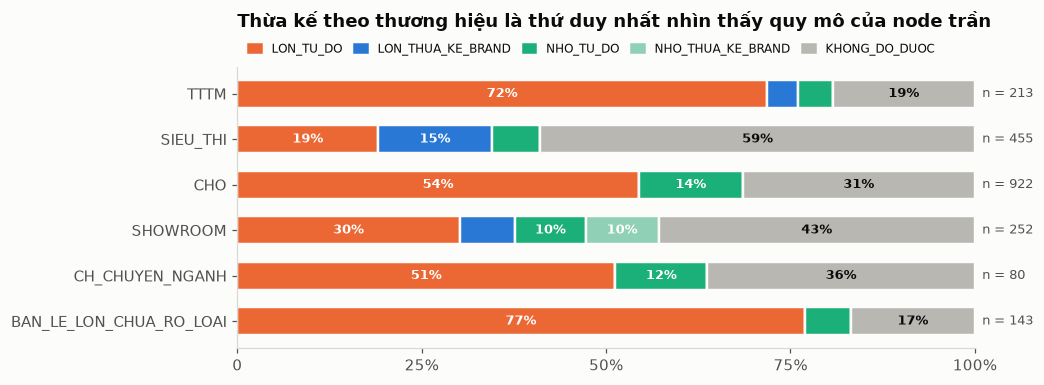

In [25]:
# [DATA] sinh cột: hang_tm, quy_mo_tm, quy_mo_nguon
# 4A — LOẠI HÌNH và QUY MÔ là hai câu hỏi khác nhau, tách thành hai cột.
# Loại hình gán từ CAO xuống THẤP: một POI vừa `shop=mall` vừa tên "siêu thị" là TTTM.
# Nhóm 420 dòng `building=retail` không có `shop` nào ("Đại lý Toyota", "Cần Thơ Ford",
# "Coopmart Đồng Phú", "FamilyMart") vẫn nói rõ loại hình — qua THƯƠNG HIỆU. Gán hạng theo
# brand là cách duy nhất chạm tới nhóm này, và nó đúng tinh thần trục 3 của lớp: danh tính
# thương hiệu là bằng chứng, không phải suy đoán.
BRAND_HANG = {
    "TTTM": r"\bvincom\b|\baeon\b|lotte department|\bparkson\b|crescent mall|vivo ?city|\bsc ?vivo",
    # `bach hoa xanh`/`satrafoods` BỎ khỏi đây: chúng là minimart (đo được 308 và 187 m²),
    # để ở đây là nâng hạng một định dạng nhỏ BẰNG ĐỊNH NGHĨA — đúng lỗi của `department_store`.
    # `\bgo!` không neo trái thì khớp "Shop&Go!" (chuỗi tiện lợi) ⇒ thêm `(?<!&)`.
    "SIEU_THI": r"\bwinmart\b(?! ?\+)|\bvinmart\b(?! ?\+)|co\.?op ?mart|co\.?op ?xtra|\bbig ?c\b"
                r"|(?<!&)\bgo!|mega market|\bemart\b|lotte mart|\bsatra mart\b",
    "SHOWROOM": r"\bhonda\b|\btoyota\b|\bford\b|\bmazda\b|\bkia\b|\bhyundai\b|\bmercedes\b"
                r"|\bvinfast\b|\byamaha\b|\bsuzuki\b|\bnissan\b|\bmitsubishi\b|\bpiaggio\b"
                r"|\bhead \b|nguyen kim|dien may xanh|the gioi di dong",
}
_bt_txt = (clean["brand"].fillna("") + " " + clean["operator"].fillna("") + " " + clean["name_norm"]).map(strip_accents)

nn_c = clean["name_norm"]

# `department_store` KHÔNG còn tự động lên TTTM (xem cổng độ phủ ở 2A). Dòng được 2D cứu
# bằng TÊN CHỢ phải về nhãn CHO, không phải TTTM.
_ds = clean["shop"].eq("department_store") & ~clean["name_dau"].fillna("").str.contains(r"\bchợ\b", na=False)
# "Plaza"/"Tower" là hậu tố TOÀ NHÀ trong tiếng Việt: veto chỉ áp cho hai token YẾU đó,
# KHÔNG áp cho tên nói thẳng "trung tâm thương mại" (đo tay 5/5 dòng bị veto đều đúng).
_tttm_manh = nn_c.str.contains(r"trung tam thuong mai|\btttm\b|thuong xa|trung tam mua sam", na=False)
_tttm_yeu = nn_c.str.contains(r"\bplaza\b|\bmall\b", na=False) & ~nn_c.str.contains(TOA_NHA_RX, regex=True, na=False)
# TÊN CHỢ thắng TAG. Người map gõ "Chợ Đêm" rồi gắn `shop=supermarket` là đang mô tả một
# CÁI CHỢ bằng từ vựng gần nhất mà preset cho phép — tên ở đây KHÔNG phải mốc tham chiếu,
# nó là chính vật thể. Ngoại lệ duy nhất: tên nói thẳng "trung tâm thương mại".
_ten_cho = clean["name_dau"].fillna("").str.contains(r"\bchợ\b", na=False)
_ten_st_thuan = nn_c.str.contains(r"sieu thi", na=False) & ~_ten_cho
_C_TTTM = (clean["shop"].eq("mall") & ~_ten_cho) | _ds | _tttm_manh | _tttm_yeu
_C_CN = (clean["shop"].isin(["books", "electronics", "furniture", "doityourself", "hardware",
                             "trade", "bathroom_furnishing", "kitchen", "bed", "houseware",
                             "interior_decoration"])
         | nn_c.str.contains(r"nha sach|dien may|noi that|vat lieu xay dung|\bvlxd\b", na=False))
_C_ST = (clean["shop"].isin(["supermarket", "wholesale", "greengrocer", "general"])
         | nn_c.str.contains(r"sieu thi|\bsupermarket\b", na=False))
hang = pd.Series("KHAC", index=clean.index)
for cond, val in [
    (_C_TTTM, "TTTM"),
    # CHUYÊN NGÀNH xét TRƯỚC siêu thị: tên đầy đủ là "Siêu thị Điện máy Nguyễn Kim", nên
    # nhánh `sieu thi` nuốt sạch nhóm này nếu đứng trước (đo: 31/31 dòng đổi nhãn đều đúng).
    (_C_CN, "CH_CHUYEN_NGANH"),
    # SIÊU THỊ trước CHỢ: "Siêu thị Điện máy Chợ Lớn", "Siêu Thị Sky Fresh" (tag marketplace)
    # bị nhánh chợ cướp mất nếu ngược lại.
    # CHỢ xét TRƯỚC siêu thị — đảo lại so với vòng 2.0. Lý do: phép thử của vòng 2.0 chạy
    # trên script đọc parquet, nơi `name_dau` ra dtype `str` ⇒ pandas dùng RE2 ⇒ `\bchợ\b`
    # khớp 1 dòng thay vì 1.417. Thiệt hại của việc đảo thứ tự VÔ HÌNH trong phép đo đó.
    # Đo lại đúng: đặt SIEU_THI trước cứu được 5 dòng và làm hỏng 36 ⇒ lỗ ròng.
    # Cái nó định cứu ("Siêu thị Điện máy Chợ Lớn") đã do nhánh CHUYÊN NGÀNH ở trên bắt.
    (((clean["amenity"].eq("marketplace")) | _ten_cho) & ~_ten_st_thuan, "CHO"),
    (_C_ST, "SIEU_THI"),
    (clean["shop"].isin(["car", "motorcycle", "car_parts", "tyres"])
     | nn_c.str.contains(r"showroom|\bshow room\b|trung bay san pham", na=False), "SHOWROOM"),
    # (nhánh CHUYÊN NGÀNH đã chạy ở trên — xem `_C_CN`)
    # Cửa hàng CHUYÊN NGÀNH quy mô lớn — nhà sách, điện máy, nội thất, vật liệu xây dựng.
    # Tách khỏi SHOWROOM vì hành vi khách khác hẳn: showroom xe là điểm đến hẹn trước, cửa
    # hàng chuyên ngành là điểm đến mua sắm cuối tuần. Nhóm này do subagent soi 190 mẫu
    # "chưa rõ loại" phát hiện: "Nhà sách Nguyễn Văn Cừ", "Nhà Sách Phương Nam" (`shop=books`,
    # 1.100–1.900 m²) đang rơi vào nhóm mập mờ dù tag đã nói rõ.
    # vòng 2 — thừa kế loại hình theo THƯƠNG HIỆU, cho nhóm không mang `shop` nào
    (_bt_txt.str.contains(BRAND_HANG["TTTM"], regex=True, na=False), "TTTM"),
    (_bt_txt.str.contains(BRAND_HANG["SIEU_THI"], regex=True, na=False), "SIEU_THI"),
    (_bt_txt.str.contains(BRAND_HANG["SHOWROOM"], regex=True, na=False), "SHOWROOM"),
]:
    hang[cond & hang.eq("KHAC")] = val
# Nhóm còn lại KHÔNG phải "rác": chúng đã qua được ngưỡng quy mô, chỉ là nguồn không nói
# loại hình. Gọi đúng tên để downstream không hiểu nhầm là "linh tinh".
hang = hang.replace("KHAC", "BAN_LE_LON_CHUA_RO_LOAI")
clean["hang_tm"] = hang
print(f"thừa kế loại hình theo thương hiệu bồi thêm:"
      f" {int((clean['shop'].isna() & ~hang.eq('BAN_LE_LON_CHUA_RO_LOAI')).sum()):,} dòng không có `shop`"
      " vẫn xác định được loại hình")

tu_do = clean["area_m2"].fillna(0) > 0
clean["quy_mo_tm"] = np.select(
    [tu_do & clean["area_m2"].ge(DT_LON), tu_do & clean["area_m2"].lt(DT_LON),
     clean["brand_tier"].eq("LON"), clean["brand_tier"].eq("NHO")],
    ["LON_TU_DO", "NHO_TU_DO", "LON_THUA_KE_BRAND", "NHO_THUA_KE_BRAND"],
    default="KHONG_DO_DUOC",
)
clean["quy_mo_nguon"] = np.select([tu_do, clean["brand_tier"].notna()],
                                  ["dien_tich", "thua_ke_brand"], default="khong_co")

print(clean["hang_tm"].value_counts().to_string())
print()
print(pd.crosstab(clean["hang_tm"], clean["quy_mo_tm"]).to_string())
print(f"\nđo được quy mô: {(clean['quy_mo_nguon'].ne('khong_co')).mean():.0%}"
      f"  (diện tích {(clean['quy_mo_nguon'].eq('dien_tich')).mean():.0%}"
      f" + thừa kế thương hiệu {(clean['quy_mo_nguon'].eq('thua_ke_brand')).mean():.0%})")

fig, ax = plt.subplots(figsize=(9.6, 3.6))
QM = ["LON_TU_DO", "LON_THUA_KE_BRAND", "NHO_TU_DO", "NHO_THUA_KE_BRAND", "KHONG_DO_DUOC"]
QM_C = {"LON_TU_DO": ORANGE, "LON_THUA_KE_BRAND": BLUE, "NHO_TU_DO": GREEN,
        "NHO_THUA_KE_BRAND": "#8fd0b6", "KHONG_DO_DUOC": GRAY}
HG = [h for h in ["TTTM", "SIEU_THI", "CHO", "SHOWROOM", "CH_CHUYEN_NGANH",
                  "BAN_LE_LON_CHUA_RO_LOAI"] if h in set(clean["hang_tm"])]
tab = pd.crosstab(clean["hang_tm"], clean["quy_mo_tm"]).reindex(index=HG, columns=QM).fillna(0)
share = tab.div(tab.sum(axis=1), axis=0)
left = np.zeros(len(tab))
for q in QM:
    v = share[q].values
    ax.barh(tab.index, v, left=left, color=QM_C[q], height=0.62, edgecolor=BG, linewidth=1.6)
    for y, p in enumerate(v):
        if p > 0.08:
            ax.text(left[y] + p / 2, y, f"{p:.0%}", ha="center", va="center", fontsize=8.5,
                    color="#ffffff" if q != "KHONG_DO_DUOC" else INK, fontweight="bold")
    left += v
for y, ten in enumerate(tab.index):
    ax.text(1.01, y, f"n = {fmt(tab.loc[ten].sum())}", va="center", fontsize=8.5, color=MUTED)
ax.set_xlim(0, 1)
ax.set_xticks([0, .25, .5, .75, 1]); ax.set_xticklabels(["0", "25%", "50%", "75%", "100%"])
ax.invert_yaxis(); ax.grid(visible=False)
ax.set_title("Thừa kế theo thương hiệu là thứ duy nhất nhìn thấy quy mô của node trần", pad=26, loc="left")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=QM_C[q]) for q in QM], labels=QM,
          ncol=5, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False, fontsize=8,
          handlelength=1.1, columnspacing=1.0)
fig.tight_layout()
plt.show()

In [26]:
# [DATA] sinh cột: container_uid, fragment_group
# 4B — ĐẾM CƠ SỞ, KHÔNG ĐẾM DÒNG. Bệnh riêng của lớp này: các gian hàng bên trong một TTTM
# được map thành POI riêng, và cả toà TTTM cũng là một polygon ⇒ đếm thô là đếm cả trung tâm
# lẫn từng gian hàng của nó.
from shapely import wkb
from shapely.geometry import Point
from shapely.strtree import STRtree

PTS = [Point(x, y) for x, y in zip(clean["lng"].values, clean["lat"].values)]
TREE = STRtree(PTS)
UIDS = clean["uid"].values

vung = clean[clean["is_area"] & clean["geometry_wkb"].notna()].copy()
vung["_geom"] = [wkb.loads(bytes(x)) for x in vung["geometry_wkb"]]
vung = vung[[g.is_valid and g.area > 0 for g in vung["_geom"]]]

container = {}
for i, geom in vung.sort_values("area_m2", ascending=False)["_geom"].items():
    self_uid = vung.at[i, "uid"]
    idx = TREE.query(geom)
    if not len(idx):
        continue
    for j in idx[[geom.contains(PTS[k]) for k in idx]]:
        if UIDS[j] != self_uid:
            container[UIDS[j]] = self_uid

clean["container_uid"] = clean["uid"].map(container)
co_ten = clean["name"].notna()
key = clean.loc[co_ten, ["h3_r8", "name_norm"]].astype(str).agg("|".join, axis=1)
clean["fragment_group"] = key[key.duplicated(keep=False)].reindex(clean.index)

n_row, n_ct = len(clean), int(clean["container_uid"].notna().sum())
print(f"dòng nằm TRONG một polygon thương mại khác: {n_ct:,}"
      f"  → đếm CƠ SỞ: {n_row - n_ct:,} thay vì {n_row:,} ({n_ct / n_row:.1%} đếm đôi)")
print(f"nhóm trùng tên trong cùng ô H3: {clean['fragment_group'].nunique():,} nhóm,"
      f" {clean['fragment_group'].notna().sum():,} dòng")
print("\n5 polygon chứa nhiều POI con nhất (ứng viên TTTM thật):")
for u, k in clean["container_uid"].value_counts().head(5).items():
    r = clean.loc[clean["uid"].eq(u)].iloc[0]
    print(f"  {u:22s} {k:3d} POI con — {r['name'] or '(vô danh)'} | {r['hang_tm']} | {r['area_m2']:,.0f} m²")

dòng nằm TRONG một polygon thương mại khác: 254  → đếm CƠ SỞ: 1,811 thay vì 2,065 (12.3% đếm đôi)
nhóm trùng tên trong cùng ô H3: 46 nhóm, 94 dòng

5 polygon chứa nhiều POI con nhất (ứng viên TTTM thật):
  way:489086379            7 POI con — Chợ đầu mối Bình Điền | CHO | 318,062 m²
  way:1313432484           7 POI con — Chợ đầu mối Nông sản Thực phẩm Hóc Môn | CHO | 77,776 m²
  way:930229621            6 POI con — Chợ Long Biên | CHO | 27,592 m²
  way:1489816486           6 POI con — LePARC by Gamuda | TTTM | 15,608 m²
  way:839663172            5 POI con — Vincom Mega Mall Smart City | TTTM | 23,076 m²


## Bước 4C — THƯỚC NGOÀI: 7.787 trạm sạc thật

Mọi cổng recall của chuỗi EDA tới giờ đều đo bằng **chính dữ liệu OSM** — tag dò tag, tên
dò tên. Cell này lần đầu đưa vào một **công cụ đo hoàn toàn bên ngoài**: vị trí 7.787 trạm
sạc thật trong `store/p/*/stations.parquet`. Nó không biết gì về `shop=*`, không đọc tên,
và không do người viết notebook này tạo ra.

Đại lượng: `d` = khoảng cách tới trạm gần nhất; `near` = `d ≤ 100 m`.

**Khử nhiễu mật độ là bắt buộc.** Trạm sạc tập trung ở lõi đô thị, nên *mọi* POI đô thị đều
có `near` cao — so thẳng với tỷ lệ nền toàn pool là so nhầm. Nên mỗi POI được so với
**kỳ vọng của chính ô H3 r8 chứa nó**, tính từ các POI hàng xóm cùng ô (leave-one-out):

```
lift = tỷ lệ near quan sát  /  tỷ lệ near kỳ vọng từ hàng xóm cùng ô
```

`lift > 1` nghĩa là: *trong cùng một khu*, loại POI này gần trạm hơn hàng xóm của nó.

⚠️ **Vòng lặp nhân quả — đọc trước khi diễn giải.** Thước này đo "đã được phục vụ", KHÔNG
đo "nên đặt trạm". Với `amenity=charging_station` nó đo chính nó; với VinFast nó đo việc
V-Green đặt trạm tại chính đại lý của hãng. Vì vậy nó **hợp lệ để kiểm PHÂN LOẠI**
(cái này có thật là TTTM không?) và **không hợp lệ để chọn vị trí** — ở bài toán chọn vị
trí, lift cao có nghĩa gần với *đã bão hoà* hơn là *còn trống*.


In [27]:
# [DATA] sinh cột: d_tram, near_tram
# 4C — nạp thước ngoài. Không sửa gì của lớp; chỉ ĐO.
import glob
from sklearn.neighbors import BallTree

_fs = sorted(glob.glob(str(ROOT / "store/p/*/stations.parquet")))
st = pd.concat([pd.read_parquet(f) for f in _fs], ignore_index=True)
_tree = BallTree(np.radians(st[["lat", "lng"]].values), metric="haversine")
R_TRAI_DAT = 6_371_000.0
NGUONG_GAN = 100.0

def do_khoang_cach(df):
    return _tree.query(np.radians(df[["lat", "lng"]].values), k=1)[0][:, 0] * R_TRAI_DAT

print(f"thước ngoài: {len(st):,} trạm sạc thật từ {len(_fs)} tỉnh")

# Nền khử nhiễu, tính trên TOÀN pool đầu vào (không chỉ lớp này).
poi["d_tram"] = do_khoang_cach(poi)
poi["near_tram"] = (poi["d_tram"] <= NGUONG_GAN).astype(float)
_g = poi.groupby("h3_r8")["near_tram"].agg(["sum", "size"])
_j = poi[["h3_r8"]].join(_g, on="h3_r8")
poi["ky_vong_o"] = (_j["sum"] - poi["near_tram"]) / (_j["size"] - 1).clip(lower=1)
NEN = poi["near_tram"].mean()
print(f"nền toàn pool ({len(poi):,} POI): {NEN:.2%} có trạm trong {NGUONG_GAN:.0f} m")

clean["d_tram"] = do_khoang_cach(clean)
clean["near_tram"] = (clean["d_tram"] <= NGUONG_GAN).astype(float)
clean["ky_vong_o"] = poi.set_index("uid")["ky_vong_o"].reindex(clean["uid"]).values

def bang_lift(nhan_mask, nmin=20):
    r = []
    for k, m in nhan_mask:
        n = int(m.sum())
        if n < nmin:
            continue
        o = clean.loc[m, "near_tram"].mean()
        e = clean.loc[m, "ky_vong_o"].mean()
        r.append(dict(nhom=k, n=n, gan=100 * o, ky_vong=100 * e,
                      lift=o / e if e > 0 else np.nan,
                      tv_m=clean.loc[m, "d_tram"].median()))
    return pd.DataFrame(r).sort_values("lift", ascending=False)

_hg = bang_lift([(h, clean["hang_tm"].eq(h)) for h in clean["hang_tm"].unique()])
print("\nTHEO NHÃN LOẠI HÌNH:")
print(_hg.round(2).to_string(index=False))

_t = clean["hang_tm"].eq("TTTM")
_src = bang_lift([
    ("TTTM · shop=mall", _t & clean["shop"].eq("mall")),
    ("TTTM · shop=department_store", _t & clean["shop"].eq("department_store")),
    ("TTTM · vào bằng tên/brand", _t & clean["shop"].isna()),
])
print("\nTHEO NGUỒN BẰNG CHỨNG, trong cùng nhãn TTTM:")
print(_src.round(2).to_string(index=False))


thước ngoài: 7,787 trạm sạc thật từ 34 tỉnh


nền toàn pool (178,680 POI): 2.87% có trạm trong 100 m

THEO NHÃN LOẠI HÌNH:
                   nhom   n   gan  ky_vong  lift   tv_m
                   TTTM 213 24.88     8.62  2.89 327.78
               SHOWROOM 252 19.84     8.61  2.30 371.23
               SIEU_THI 455 12.31     6.21  1.98 497.42
        CH_CHUYEN_NGANH  80 11.25     6.27  1.79 482.09
BAN_LE_LON_CHUA_RO_LOAI 143  8.39     5.36  1.57 732.23
                    CHO 922  2.28     2.92  0.78 681.60

THEO NGUỒN BẰNG CHỨNG, trong cùng nhãn TTTM:
                     nhom   n   gan  ky_vong  lift   tv_m
         TTTM · shop=mall 143 30.77     9.61  3.20 290.21
TTTM · vào bằng tên/brand  51 13.73     5.65  2.43 562.86


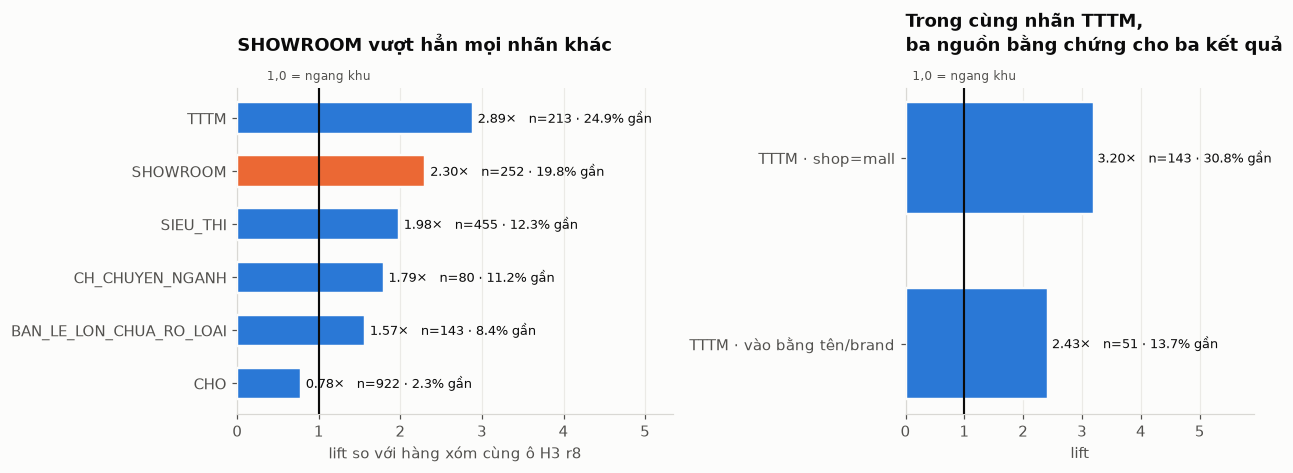

Đọc biểu đồ — thước ngoài, độc lập hoàn toàn với tag và tên:
  • TTTM · shop=mall                 lift 3.20×  (30.8% có trạm ≤100 m, trung vị 290 m)
  • TTTM · vào bằng tên/brand        lift 2.43×  (13.7% có trạm ≤100 m, trung vị 563 m)

  Nhóm `shop=department_store` KHÔNG còn trong nhãn TTTM — cổng độ phủ ở 2A đã loại nó.
  Vòng trước nhóm này có 651 dòng với lift 1,03 (≈ nền đô thị) trong khi `shop=mall`
  đạt 3,12: một TTTM thật là nơi vận hành trạm ĐI TÌM, nhóm kia thì không.
  Ba thước độc lập cùng chỉ một hướng — hình học 2,5% polygon · ngôn ngữ 96% tên
  không từ khoá · hạ tầng thật lift 1,03. Đó là căn cứ của cổng độ phủ.


In [28]:
# BIỂU ĐỒ 3 — thước ngoài PHÂN GIẢI được nhóm mà thước trong không phân giải.
# Trái : lift theo nhãn loại hình. Phải : bên trong nhãn TTTM, tách theo nguồn bằng chứng.
# Nếu `department_store` thật là TTTM thì hai cột phải Phải bằng nhau. Chúng không bằng.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.6, 4.4), gridspec_kw={"width_ratios": [1.25, 1]})

def _thanh(ax, d, nhan_col, mau, tieu_de, xlab):
    d = d.sort_values("lift")
    y = np.arange(len(d))
    ax.barh(y, d["lift"], color=mau, height=0.6, edgecolor=BG, linewidth=1.6, zorder=3)
    ax.axvline(1.0, color=INK, linewidth=1.4, zorder=4)
    ax.annotate("1,0 = ngang khu", (1.0, 1.0), xycoords=("data", "axes fraction"), fontsize=8,
                color=MUTED, ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")
    for i, (_, r) in enumerate(d.iterrows()):
        ax.text(r["lift"] + 0.06, i, f'{r["lift"]:.2f}×   n={int(r["n"])} · {r["gan"]:.1f}% gần',
                va="center", fontsize=8.5, color=INK)
    ax.set_yticks(y); ax.set_yticklabels(d[nhan_col])
    ax.set_xlim(0, float(d["lift"].max()) * 1.85)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel(xlab); ax.set_title(tieu_de, loc="left", pad=24)

_hgp = _hg.copy()
_thanh(a1, _hgp, "nhom",
       [ORANGE if n == "SHOWROOM" else BLUE for n in _hgp.sort_values("lift")["nhom"]],
       "SHOWROOM vượt hẳn mọi nhãn khác", "lift so với hàng xóm cùng ô H3 r8")

_thanh(a2, _src, "nhom",
       [ORANGE if "department" in n else BLUE for n in _src.sort_values("lift")["nhom"]],
       "Trong cùng nhãn TTTM,\nba nguồn bằng chứng cho ba kết quả", "lift")
fig.tight_layout()
plt.show()

_m = _src.set_index("nhom")
print("Đọc biểu đồ — thước ngoài, độc lập hoàn toàn với tag và tên:")
for _k in _src["nhom"]:
    _r = _m.loc[_k]
    print(f"  • {_k:32s} lift {_r['lift']:.2f}×"
          f"  ({_r['gan']:.1f}% có trạm ≤100 m, trung vị {_r['tv_m']:.0f} m)")
if "TTTM · shop=department_store" not in _m.index:
    print()
    print("  Nhóm `shop=department_store` KHÔNG còn trong nhãn TTTM — cổng độ phủ ở 2A đã loại nó.")
    print("  Vòng trước nhóm này có 651 dòng với lift 1,03 (≈ nền đô thị) trong khi `shop=mall`")
    print("  đạt 3,12: một TTTM thật là nơi vận hành trạm ĐI TÌM, nhóm kia thì không.")
    print("  Ba thước độc lập cùng chỉ một hướng — hình học 2,5% polygon · ngôn ngữ 96% tên")
    print("  không từ khoá · hạ tầng thật lift 1,03. Đó là căn cứ của cổng độ phủ.")


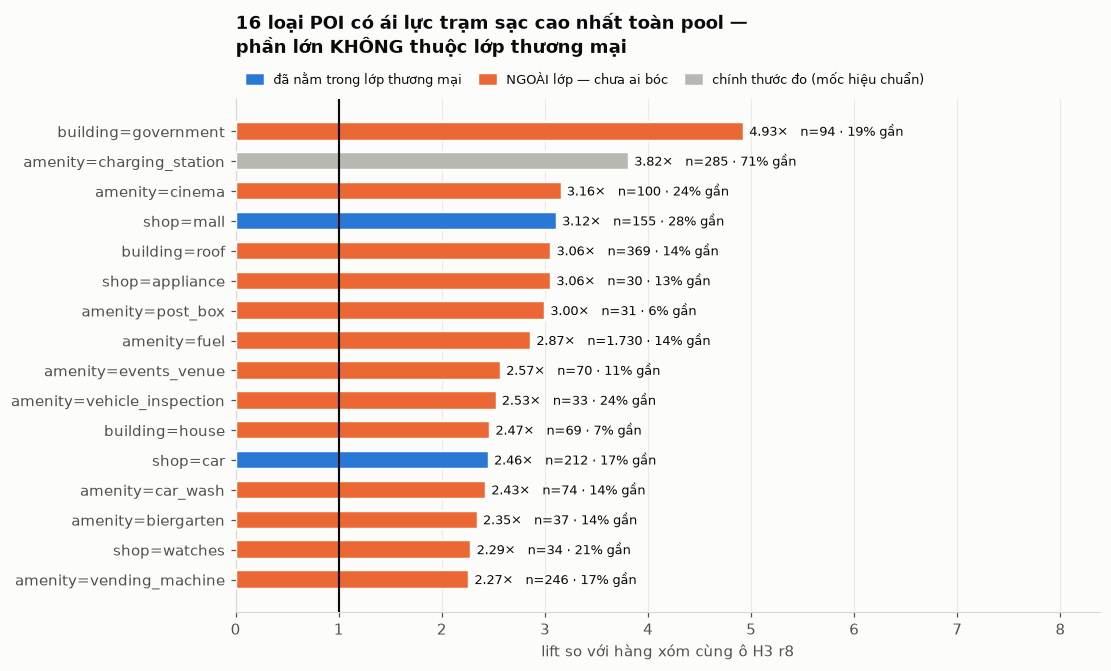

SHOWROOM tách theo thương hiệu — vì sao KHÔNG được đọc con số gộp:
                     nhom  n   gan  ky_vong  lift   tv_m
       SHOWROOM · VinFast 36 80.56    28.19  2.86  23.64
SHOWROOM · ô tô hãng khác 75 12.00     5.09  2.36 482.19
        SHOWROOM · xe máy 28 14.29     7.80  1.83 449.70

  VinFast tách hẳn khỏi phần còn lại. Đó KHÔNG phải phát hiện về showroom —
  đó là V-Green đặt trạm tại chính đại lý của hãng. Gộp ba nhóm lại rồi kết luận
  "showroom có ái lực trạm cao" là để một quan hệ ĐỊNH NGHĨA giả dạng phát hiện.
  Showroom ô tô hãng khác và xe máy chỉ nhỉnh hơn nền — đó mới là tín hiệu thật,
  và nó yếu hơn nhiều so với con số gộp.


In [29]:
# BIỂU ĐỒ 4 — quét TOÀN POOL để tìm loại hình có ái lực trạm cao, KHÔNG giới hạn ở lớp này.
# Câu hỏi không còn là "lớp thương mại có đúng không" mà là "công cụ mới này nói gì mà cả
# chuỗi chưa hỏi". Quét mọi giá trị của shop/amenity/building/landuse trên 178k POI.
def quet(cot, nmin=30):
    r = []
    for v in poi[cot].dropna().unique():
        m = poi[cot].eq(v)
        n = int(m.sum())
        if n < nmin:
            continue
        o, e = poi.loc[m, "near_tram"].mean(), poi.loc[m, "ky_vong_o"].mean()
        if e <= 0 or o < 0.05:
            continue
        r.append(dict(nhom=f"{cot}={v}", n=n, gan=100 * o, lift=o / e))
    return pd.DataFrame(r)

_sweep = pd.concat([quet(c) for c in ["shop", "amenity", "building", "landuse"]], ignore_index=True)
_sweep = _sweep.sort_values("lift", ascending=False).head(16)

# Loại hình đó đã nằm trong lớp thương mại chưa?
_trong_lop = set(clean["shop"].dropna().map(lambda v: f"shop={v}")) | {"amenity=marketplace"}
_sweep["o_trong_lop"] = _sweep["nhom"].isin(_trong_lop)
# `charging_station` là chính THƯỚC ĐO tự phát hiện nó — giữ lại làm mốc hiệu chuẩn
# (thước hoạt động), nhưng tô XÁM để không ai đọc nó như một phát hiện.
_sweep["la_thuoc"] = _sweep["nhom"].eq("amenity=charging_station")

fig, ax = plt.subplots(figsize=(10.2, 6.2))
d = _sweep.sort_values("lift")
y = np.arange(len(d))
cols = [GRAY if x else (BLUE if t else ORANGE)
        for t, x in zip(d["o_trong_lop"], d["la_thuoc"])]
ax.barh(y, d["lift"], color=cols, height=0.62, edgecolor=BG, linewidth=1.6, zorder=3)
ax.axvline(1.0, color=INK, linewidth=1.4, zorder=4)
for i, (_, r) in enumerate(d.iterrows()):
    ax.text(r["lift"] + 0.05, i, f'{r["lift"]:.2f}×   n={fmt(r["n"])} · {r["gan"]:.0f}% gần',
            va="center", fontsize=8.5, color=INK)
ax.set_yticks(y); ax.set_yticklabels(d["nhom"])
ax.set_xlim(0, float(d["lift"].max()) * 1.7)
ax.grid(axis="y", visible=False)
ax.set_xlabel("lift so với hàng xóm cùng ô H3 r8")
ax.set_title("16 loại POI có ái lực trạm sạc cao nhất toàn pool —\nphần lớn KHÔNG thuộc lớp thương mại",
             loc="left", pad=30)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in [BLUE, ORANGE, GRAY]],
          labels=["đã nằm trong lớp thương mại", "NGOÀI lớp — chưa ai bóc",
                  "chính thước đo (mốc hiệu chuẩn)"],
          ncol=3, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False, fontsize=8.5,
          handlelength=1.2, columnspacing=1.4)
fig.tight_layout()
plt.show()

# SHOWROOM: tách theo thương hiệu để lộ vòng lặp nhân quả.
_sr = clean["hang_tm"].eq("SHOWROOM")
_ct2 = (clean["brand"].fillna("") + " " + clean["operator"].fillna("") + " " + clean["name_norm"]).map(strip_accents)
_srb = bang_lift([
    ("SHOWROOM · VinFast", _sr & _ct2.str.contains(r"\bvinfast\b", na=False)),
    ("SHOWROOM · ô tô hãng khác", _sr & _ct2.str.contains(
        r"\btoyota\b|\bford\b|\bkia\b|\bmazda\b|\bhyundai\b|\bmercedes\b|\bnissan\b|\bmitsubishi\b", na=False)),
    ("SHOWROOM · xe máy", _sr & _ct2.str.contains(r"\bhonda\b|\byamaha\b|\bsuzuki\b|\bpiaggio\b|\bhead ", na=False)),
])
print("SHOWROOM tách theo thương hiệu — vì sao KHÔNG được đọc con số gộp:")
print(_srb.round(2).to_string(index=False))
print("\n  VinFast tách hẳn khỏi phần còn lại. Đó KHÔNG phải phát hiện về showroom —")
print("  đó là V-Green đặt trạm tại chính đại lý của hãng. Gộp ba nhóm lại rồi kết luận")
print('  "showroom có ái lực trạm cao" là để một quan hệ ĐỊNH NGHĨA giả dạng phát hiện.')
print("  Showroom ô tô hãng khác và xe máy chỉ nhỉnh hơn nền — đó mới là tín hiệu thật,")
print("  và nó yếu hơn nhiều so với con số gộp.")


## Bước 5 — FINAL và bộ CÒN LẠI

In [30]:
final = clean.copy()
out_final = EDA_DIR / f"poi_{LOP}_{SCOPE}_final.parquet"
final.drop(columns="tags_dict").to_parquet(out_final, index=False)
print(f"final: {len(final):,} dòng, {final.shape[1] - 1} cột → {out_final.name}")
print("\nhang_tm  :", final["hang_tm"].value_counts().to_dict())
print("quy_mo_tm:", final["quy_mo_tm"].value_counts().to_dict())
print(f"số CƠ SỞ (lọc container_uid): {final['container_uid'].isna().sum():,}")
print()
print(final.groupby("hang_tm")["province_name"].value_counts().unstack(0).fillna(0).astype(int).to_string())

final: 2,065 dòng, 66 cột → poi_thuongmai_7tinh_final.parquet

hang_tm  : {'CHO': 922, 'SIEU_THI': 455, 'SHOWROOM': 252, 'TTTM': 213, 'BAN_LE_LON_CHUA_RO_LOAI': 143, 'CH_CHUYEN_NGANH': 80}
quy_mo_tm: {'LON_TU_DO': 969, 'KHONG_DO_DUOC': 760, 'NHO_TU_DO': 213, 'LON_THUA_KE_BRAND': 98, 'NHO_THUA_KE_BRAND': 25}
số CƠ SỞ (lọc container_uid): 1,811

hang_tm                BAN_LE_LON_CHUA_RO_LOAI  CHO  CH_CHUYEN_NGANH  SHOWROOM  SIEU_THI  TTTM
province_name                                                                                 
Thành phố Cần Thơ                            2   69                8        13        31    14
Thành phố Hà Nội                            36  209               32        84       186    66
Thành phố Hải Phòng                          7   58                5        14        15    11
Thành phố Hồ Chí Minh                       46  388               18       104       175    93
Thành phố Đà Nẵng                           27   72                2        16      

In [31]:
# [DATA] sinh file: poi_extended_<scope>_con_lai_sau_thuongmai.parquet
da_thuoc_lop = set(final["uid"])
con_lai = poi[~poi["uid"].isin(da_thuoc_lop)].copy()
out_pool = EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP}.parquet"

# HỢP ĐỒNG BÀN GIAO — túi trao cho lớp sau phải có ĐÚNG bộ cột của túi nhận vào, không hơn.
# Vòng trước mỗi lớp để lại biến công tác của mình: chuỗi phình 39 → 75 cột, và `is_tm` đi
# tới tận `con_lai_cuoi`. Cái tên đó mời gọi đúng cách đọc SAI — `is_tm=True` nghĩa là "được
# bước 1 TUYỂN rồi bước 3 loại" (17.061 dòng), không phải "là POI thương mại" (2.082 dòng).
# Neo vào schema của chính file đầu vào thì hợp đồng tự kiểm, không cần bảo trì danh sách.
_cot_vao = list(pq.read_schema(IN_POOL).names)
_thua = [c for c in con_lai.columns if c not in _cot_vao]
con_lai_ra = con_lai.reindex(columns=_cot_vao)
assert list(con_lai_ra.columns) == _cot_vao, "túi bàn giao lệch schema so với túi nhận vào"
con_lai_ra.to_parquet(out_pool, index=False)
print(f"hợp đồng bàn giao: {len(_cot_vao)} cột (bằng túi vào) — dọn {len(_thua)} biến công tác: {_thua}")

print(f"bộ vào    : {len(poi):,}")
print(f"đã bóc ra : {len(da_thuoc_lop):,}")
print(f"CÒN LẠI   : {len(con_lai):,}  → {out_pool.name}")

_con = removed["uid"].isin(con_lai["uid"]).sum()
assert _con == len(removed), f"mất {len(removed) - _con} dòng bị luật xoá khỏi bộ còn lại"
print(f"✓ {len(removed):,} dòng bị {removed['drop_reason'].nunique()} luật xoá đều nằm lại trong bộ còn lại")

for ten_lop in ["chungcu", "luutru"]:
    f = EDA_DIR / f"poi_{ten_lop}_{SCOPE}_final.parquet"
    giao = set(pq.read_table(f, columns=["uid"]).to_pandas()["uid"]) & da_thuoc_lop
    assert not giao, f"{len(giao)} uid trùng với lớp {ten_lop}"
    print(f"✓ không đếm đôi với lớp {ten_lop}")

_td = con_lai["tags"].map(parse_tags)
print("\nnguyên liệu lớp GIẢI TRÍ trong bộ còn lại:")
print("  leisure:", _td.map(lambda t: t.get("leisure")).value_counts().head(8).to_dict())

hợp đồng bàn giao: 41 cột (bằng túi vào) — dọn 14 biến công tác: ['tags_dict', 'craft', 'aeroway', 'man_made', 'historic', 'natural', 'waterway', 'barrier', 'military', 'name_dau', 'is_tm', 'd_tram', 'near_tram', 'ky_vong_o']
bộ vào    : 178,680
đã bóc ra : 2,065
CÒN LẠI   : 176,615  → poi_extended_7tinh_con_lai_sau_thuongmai.parquet


✓ 18,222 dòng bị 10 luật xoá đều nằm lại trong bộ còn lại
✓ không đếm đôi với lớp chungcu
✓ không đếm đôi với lớp luutru



nguyên liệu lớp GIẢI TRÍ trong bộ còn lại:
  leisure: {'pitch': 4343, 'park': 2271, 'swimming_pool': 877, 'garden': 717, 'playground': 391, 'sports_centre': 312, 'fitness_station': 204, 'fitness_centre': 193}


> ⚠️ **Số trong cell này là của VÒNG 1 và đã lỗi thời.** Xem bảng "VÒNG 2" ở cell
> ngay trên để lấy số hiện hành. Giữ nguyên phần dưới làm nhật ký quyết định.

---

## ⚠️ VÒNG 2 — số dưới đây THAY THẾ mọi con số trong phần CHỐT phía sau

Phần CHỐT bên dưới là của vòng 1 và **không còn khớp output**. Giữ lại làm nhật ký quyết
định, nhưng mọi con số phải đọc theo bảng này.

> Số cột "vòng 2" là của lần chạy 2026-08-09; chuỗi sẽ CHẠY LẠI từ lớp 3 sau đợt vá
> liên lớp — **mọi con số sinh lại sau lần chạy tới**, số CHỐT đọc ở output cell 4C/final.

| | vòng 1 | **vòng 2** |
|---|---|---|
| final | 3.129 | **2.065** |
| TTTM | 877 | **213** |
| SIEU_THI | 810 | **455** |
| CHO | 939 | **922** |
| SHOWROOM | 253 | **252** |
| CH_CHUYEN_NGANH | 107 | **80** |
| BAN_LE_LON_CHUA_RO_LOAI | 143 | **143** |
| polygon | 39% | **57%** |
| brand phủ (final) | "16,8%" ✗ | **12,3%** (bộ vào 3,7% · b1 13,7%) |

**Con số "16,8%" của vòng 1 không tái lập được ở bất kỳ đâu** — nó đã lan sang README lớp và
sang comment biện minh cho đầu dò recall số 1. Đó là con số cần sửa ở mọi nơi nó xuất hiện.

### Nợ vòng 1 nay ĐÓNG

- **"Ngưỡng 1.000 m² là ĐẶT TAY"** — đóng. Bước 2D đo lại bằng định dạng chuỗi (nhãn biết
  từ NGOÀI dữ liệu): khe phân tách 645–1.665 m², ngưỡng nằm giữa. Một phép đo độc lập với
  phép đã chọn ra nó.
- **"Precision chưa đo bằng thước ngoài"** — đóng. Bước 4C dùng 7.787 trạm sạc thật, khử
  nhiễu mật độ bằng ô H3 r8. Lift lớp: 1,65 → **1,87**.
- **"`BAN_LE_LON_CHUA_RO_LOAI` là nhóm nợ"** — bác. Nhóm này lành; nhóm thối nằm ở nhãn
  notebook tin nhất (`TTTM`).

### Cái đã sai ở vòng 1, và vì sao

`shop=department_store` được phong TTTM nguyên khối: 651 dòng, **20,8% final**, trong đó
2,5% có polygon và 96% tên không mang một từ khoá TTTM nào. Nguồn gốc là lỗi OSM (preset iD
dịch `department_store` = "cửa hàng bách hoá" → tạp hoá bị gắn hàng loạt), nhưng **việc không
phát hiện là lỗi thuật toán**: cột `poly` đã được tính và IN RA ngay tại 2A rồi không được
dùng làm điều kiện gì.

Đó là mẫu hình chung của cả vòng 1 — *notebook tính ra bằng chứng phản bác, in nó ra, rồi
không cho nó quyền phủ quyết*. Ba chỗ khác cùng bệnh: `brand_tier=NHO` của Bách hoá Xanh
(308 m²) bị `shop=supermarket ∈ BAC_LON` ghi đè; 96% tên không từ khoá chưa bao giờ được hỏi;
107 dòng `CHO` vào bằng tên mà không ai đòi tag.

### Precision đo bằng mẫu tay

| | vòng 1 | vòng 2 |
|---|---|---|
| mẫu 50, đúng/sai/KKL | 30 / 16 / 4 | 38 / 7 / 5 |
| precision | **60,0%** (Wilson 46–72%) | **76%** (84% nếu loại KKL) |

Nhóm bị loại cũng được lấy mẫu 40 dòng: 36 đúng. Hai ca giết oan (`Takashimaya`,
`Chợ vải Soái Kình Lâm`) đã được luật cứu-ngược ở 2D xử lý.

### Luật vòng 2 và số dòng mỗi luật cắt

`BAN_LE_NHO` 13.543 · `DICH_VU_KHONG_BAN_LE` 2.451 · `HA_TANG_DUONG` 764 ·
`AMENITY_LOP_KHAC` 707 (gồm 246 máy bán tự động + xe đạp công cộng dồn vào đây ở bản
2.1 — `MAY_BAN_TU_DONG` giờ cắt 0) · `NHA_PHO_BUILDING_RETAIL` 232 ·
`SIEU_THI_KHONG_BANG_CHUNG` 217 · `DINH_DANG_NHO` 138 · `O_DAT_VO_DANH` 138 ·
`AMENITY_LOP_DA_BOC` 26 · `TEN_LOAI_KHAC` 6 — (số lần chạy 2026-08-09, sinh lại sau
lần chạy tới)

### Fix đã THỬ rồi BỎ (ghi lại để không ai làm lại)

- **Đòi bằng chứng thứ hai cho mọi `amenity=marketplace` không có chữ "chợ" trong tên** —
  bỏ. Lấy mẫu 12/70 dòng bị nó cắt: 6 là chợ KHÔNG TÊN, cộng "Nguyễn Công Trứ", "Chọ mini".
  Nó phán theo TÊN, đúng thứ nguyên tắc của lớp cấm. Bản hẹp (chỉ cắt marketplace mang tên
  chuỗi tiện lợi) thì lại bị luật `DINH_DANG_NHO` nuốt trọn ⇒ không cần.
  **Chỉ số lift 0,858 đã suýt cho luật này qua; chỉ soi mẫu mới bắt được.**
- **Gán điều kiện phụ cho `department_store` ở bước GÁN NHÃN** — bỏ, vì cổng độ phủ ở 2A đã
  loại nhóm đó từ bước 3; đặt ở bước 4 là code chết. Việc cần làm nằm ở tấm khiên (cứu ngược).
- **Đặt SIEU_THI trước CHO trong chuỗi gán nhãn** — thử ở vòng 2.0, **thu hồi ở 2.1**.
  Nó cứu 5 dòng ("Siêu Thị Sky Fresh" mang tag `marketplace`) và làm hỏng **36** — chợ thật
  bị người map gắn `shop=supermarket|mall` ("Chợ Đêm", "chợ Hôm", "Chợ Tân Phong") bị đẩy
  sang SIEU_THI. **Lỗ ròng.** Thiệt hại vô hình lúc thẩm định vì script đo đọc parquet →
  `name_dau` ra dtype `str` → pandas dùng RE2 → `\bchợ\b` khớp 1 dòng thay vì 1.417.
  Bài học: **thẩm định bằng script đọc parquet thì phải `astype(object)` trước mọi regex
  có `\b` và chữ có dấu** — nếu không, phép đo im lặng cho ra kết luận ngược.
  Thay bằng luật đúng: TÊN CHỢ thắng TAG, trừ khi tên nói thẳng "siêu thị"/"TTTM".
- **Vô hiệu `brand` khi nó mâu thuẫn với `amenity`** — bỏ. Dòng bẩn duy nhất tìm được
  ("Lẩu dê Vườn Xoài 15" mang `brand=Circle K`) đã bị LUẬT 2 xử. 0 dòng thay đổi.

### Còn nợ

- 7/8 lớp trong chuỗi vẫn mang biến công tác sang túi bàn giao (39 → 75 cột). Lớp này đã
  đóng hợp đồng cột; các lớp khác chưa. `make check-chain` báo cảnh báo, không chặn.
- Thước ngoài (4C) chỉ hợp lệ để kiểm PHÂN LOẠI. Ở bài toán CHỌN VỊ TRÍ nó vòng lặp nhân
  quả — lift cao nghĩa là *đã được phục vụ*, không phải *nên đặt trạm*.

---



> ⚠️ **Số trong cell này là của VÒNG 1 và đã lỗi thời.** Xem bảng "VÒNG 2" ở cell
> ngay trên để lấy số hiện hành. Giữ nguyên phần dưới làm nhật ký quyết định.

---

## ✅ CHỐT LỚP THƯƠNG MẠI

Đầu ra: `data/qa/eda/poi_thuongmai_7tinh_final.parquet`
(+ `poi_extended_7tinh_con_lai_sau_thuongmai.parquet` cho lớp sau).

| Cột | Nghĩa |
| --- | --- |
| `hang_tm` | `TTTM` · `SIEU_THI` · `CHO` · `SHOWROOM` (xe) · `CH_CHUYEN_NGANH` (nhà sách/điện máy/nội thất/VLXD) · `BAN_LE_LON_CHUA_RO_LOAI` |
| `quy_mo_tm` | `LON_TU_DO` / `NHO_TU_DO` (đo bằng diện tích) · `LON_THUA_KE_BRAND` / `NHO_THUA_KE_BRAND` (thừa kế thương hiệu) · `KHONG_DO_DUOC` |
| `quy_mo_nguon` | `dien_tich` / `thua_ke_brand` / `khong_co` — bằng chứng đến từ đâu |
| `brand_tier`, `brand_n`, `brand_dt` | định dạng cửa hàng học được từ chính thương hiệu đó |
| `container_uid` | dòng nằm trong polygon thương mại khác (gian hàng trong TTTM/chợ) — **đếm CƠ SỞ thì bỏ** |
| `mixed_use` | TTTM mang thêm tag chức năng khác |

### Lỗi CÒN LẠI — đọc trước khi dùng file

**Sai số ảnh hưởng tới con số cuối**

1. **Ngưỡng "loại lớn" 1.000 m² là ĐẶT TAY.** Quét 7 mức cho thấy tập bậc lớn ổn định trong
   khoảng 750–1.500 m²; ngoài khoảng đó tập đổi thành phần (dưới thì nở ra bằng cửa hàng
   phố, trên thì mất `supermarket`). Chọn 1.000 vì nằm giữa vùng ổn định, không vì có mốc
   khách quan nào.
2. **53% lớp không đo được quy mô.** Diện tích phủ 43%, thừa kế thương hiệu bồi thêm 4%.
   Nhóm `KHONG_DO_DUOC` **không** được đọc là "nhỏ".
3. **Thừa kế thương hiệu chỉ phủ 13% nhóm mù** (2.122/16.223) vì chỉ 37/253 thương hiệu có
   đủ 3 điểm bán đo được diện tích. Hạ ngưỡng xuống 2 sẽ phủ rộng hơn nhưng một polygon vẽ
   sai kéo cả chuỗi — chưa thử.
4. **`BAN_LE_LON_CHUA_RO_LOAI` (169 dòng) là nhóm nợ.** Subagent soi 190 mẫu: ngoài Đà Nẵng
   chúng là khối bán lẻ lớn thật (trung vị ~900–2.100 m²) nhưng **không có tên** nên không
   xác nhận được loại hình. Rủi ro thấp hơn nhóm Đà Nẵng nhưng chưa xác minh.

**Giới hạn của NGUỒN**

5. **Một CỤM MAP HÀNG LOẠT đã bị bắt và cắt** (`drop_reason == "NHA_PHO_BUILDING_RETAIL"`).
   Đà Nẵng: `building=retail` không loại hình có tỷ lệ **7,07‰** so với 1,4–1,9‰ ở các tỉnh
   khác (≈4×), 91% không tên, **diện tích trung vị 56–73 m²** so với 894–2.098 m² ở nơi
   khác. Đó là cả dãy NHÀ MẶT PHỐ được gắn `building=retail`. Luật cắt theo **diện tích**
   chứ không theo tỉnh, để `SCOPE="vn"` vẫn đúng ở nơi không có cụm này.
6. **`landuse=commercial` (2.038 dòng) CỐ Ý không thuộc lớp này** — 55% không tên, trung vị
   2 tag, mẫu là "Công Ty TNHH Nhà Đất", "TCI Building". Đó là ô đất DỊCH VỤ-VĂN PHÒNG.
   **Bàn giao cho lớp văn phòng.**
7. **Cây xăng (1.665) và ngân hàng (1.774) không thuộc lớp này** — transit và dịch vụ công.
   Đã đo và ghi ở đầu dò MỀM để lớp tương ứng biết chúng còn nguyên trong bộ còn lại.

**Chưa đo / chưa chốt**

8. **Gian hàng trong chợ chưa gỡ.** "Ngành hàng trầu cau vỏ" (1.699 m²) là một quầy bên
   trong chợ, được tách thành POI riêng và thừa hưởng diện tích của cả khối. `container_uid`
   bắt được nhóm này (264 dòng, 8,6%) nhưng chưa hợp nhất thực thể.
9. **`hang_tm` chưa phân biệt chợ dân sinh với chợ đầu mối.** "Chợ đầu mối Bình Điền"
   (318.062 m², 7 POI con) và một chợ cóc 200 m² cùng nhãn `CHO`. Có sẵn `area_m2` để tách,
   chưa làm.
10. **Precision chưa đo bằng thước ngoài.** Cổng recall cứng = 0 sau khi nhánh F được sinh
    ra từ chính cổng đó; nhưng chưa có gold set. 146 dòng tên có "siêu thị/TTTM" bị xoá —
    85 trong đó là **tên trạm buýt** (đúng như 143 ca "chung cư" của lớp nhà ở), đã soi.

### Bàn giao — bài học và trục KHÔNG dùng lại được

- **⚠ BẪY MỚI, ảnh hưởng CẢ CHUỖI: `\b` trong regex không an toàn với chữ có dấu.**
  pandas trả cột chuỗi ở dtype `str` (nền Arrow), và `.str.contains(regex=True)` khi đó chạy
  bằng **RE2**, nơi `\b` chỉ hiểu ASCII. `\bchợ\b` khớp **3** dòng thay vì **1.417** — trượt
  im lặng, không lỗi, không cảnh báo. Cách chữa dùng trong notebook này: ép cột về
  `astype(object)` để `.str.contains` dùng `re` của Python. **Quy tắc cho các lớp sau:**
  `\b` chỉ an toàn trên `name_norm` (đã bỏ dấu ⇒ thuần ASCII); mọi regex chạm chữ CÒN DẤU
  phải ép `object` hoặc neo biên tường minh `(?:^|[^0-9a-zA-ZÀ-ỹ])`.
- **`brand` đạt đỉnh ở lớp này và sẽ tụt mạnh ở các lớp sau.** (Vòng 1 ghi 16,8% — con số đó
  KHÔNG tái lập được; đo lại vòng 2: bộ vào 3,7% · b1 13,7% · final 12,3%.) Công viên, trường
  học, bệnh viện, cơ quan hành chính hầu như không có thương hiệu. Cơ chế **thừa kế theo
  thương hiệu** vì thế là công cụ RIÊNG của lớp này — lớp sau phải tìm trục khác.
- **Bậc `shop=*` cũng là đặc sản của lớp này.** OSM không có thang bậc tương đương cho
  `leisure=*` (công viên 2 ha và bãi cỏ 70 m² cùng là `leisure=park`/`landuse=grass`) —
  lớp giải trí sẽ phải dựng thang bậc từ **diện tích + độ phủ tên**, không có sẵn từ vựng.
- **Đã bàn giao đi:** `landuse=commercial` → lớp văn phòng · cây xăng → lớp transit ·
  ngân hàng/bưu điện → lớp dịch vụ công · 12.852 dòng `BAN_LE_NHO` (cửa hàng tiện lợi,
  tạp hoá) → **một lớp riêng đáng làm sau MVP**, tra bằng
  `drop_reason == "BAN_LE_NHO"` trong `poi_thuongmai_7tinh_b3_bi_xoa.parquet`.

---

# CHỐT SỔ LỚP THƯƠNG MẠI

Đầu ra: `data/qa/eda/poi_thuongmai_7tinh_final.parquet`
(+ `poi_extended_7tinh_con_lai_sau_thuongmai.parquet` cho lớp sau) — **2.070 dòng / 66 cột**.
Mọi bước sau **đọc `final`**, không đọc `b1`/`b3` nữa.

Bộ vào 178.680 → tuyển 20.287 (b1) → cắt 18.217 → **final 2.070**.
Mắt xích này kín: `178.680 − 2.070 = 176.610`, không uid nào biến mất, không uid nào từ hư
không, túi bàn giao đúng 41 cột như túi nhận vào. Các lớp DƯỚI có thể còn đang chạy —
`make check-chain` là nơi kiểm, đừng tin tổng chuỗi chép tay ở bất kỳ đâu.

| `hang_tm` | Số dòng | Ghi chú |
| --- | --- | --- |
| `CHO` | 922 | chợ; tên chợ THẮNG tag (người map gắn `shop=supermarket` cho chợ rất nhiều) |
| `SIEU_THI` | 455 | siêu thị loại lớn; minimart đã bị bóc ra |
| `SHOWROOM` | 252 | xe hơi/xe máy; **còn 2 dòng là trạm sạc** — xem lỗi #3 |
| `TTTM` | 218 | vòng trước là 877, phồng 4× — xem lỗi #1 |
| `BAN_LE_LON_CHUA_RO_LOAI` | 143 | **KHÔNG phải một loại hình** — xem lỗi #4 |
| `CH_CHUYEN_NGANH` | 80 | nhà sách/điện máy/nội thất/VLXD |

`quy_mo_tm`: `LON_TU_DO` 969 · `KHONG_DO_DUOC` 765 · `NHO_TU_DO` 213 · `LON_THUA_KE_BRAND` 98 · `NHO_THUA_KE_BRAND` 25
`quy_mo_nguon`: `dien_tich` 1.182 · `khong_co` 765 · `thua_ke_brand` 123
Đếm thực thể: lọc `container_uid.isna()` → **2.009**. Polygon 57%. Không tên 261.

**Precision đo tay, mẫu phân tầng 108 dòng (18/nhãn, seed 99): 84,3% (nghiêm) – 92,9% (nới).**
Vòng trước: 60,0%. Theo nhãn: `TTTM` 94,4% · `SIEU_THI` 94,1% · `CHO` 93,8% ·
`SHOWROOM` 88,2% · `CH_CHUYEN_NGANH` 87,5%.

### Lỗi CÒN LẠI — đọc trước khi dùng file

**Sai số ảnh hưởng tới con số cuối**

1. **`TTTM` vòng trước phồng 4×.** `shop=department_store` được phong TTTM nguyên khối:
   651 dòng, 2,5% có polygon, 96% tên không mang một từ khoá TTTM nào. Lỗi nguồn (preset iD
   dịch `department_store` = "cửa hàng bách hoá" → tạp hoá bị gắn hàng loạt) nhưng **không
   phát hiện là lỗi thuật toán**: cột `poly` đã được tính và IN RA ngay tại 2A rồi không
   được dùng làm điều kiện gì. Đã sửa bằng cổng độ phủ. **Mọi thống kê TTTM theo tỉnh của
   vòng trước đều sai, nặng nhất TP.HCM.**

2. **Trục quy mô MÙ ở 43% dữ liệu.** 765/2.070 dòng `KHONG_DO_DUOC`. Ở nhóm đó `quy_mo_tm`
   là **mặc định, không phải số đo** — đừng dùng nó để lọc. Mọi luật quy mô (ngưỡng 1.000 m²,
   cổng độ phủ, `SIEU_THI_KHONG_BANG_CHUNG`) chỉ chạm 57% còn lại.

3. **2 dòng là TRẠM SẠC, không phải showroom.** "Trạm sạc điện VinFast", "Trạm sạc Vinfast" —
   không mang `amenity=charging_station` nên `AMENITY_NGOAI_LOP` không bắt được, và tên chứa
   "VinFast" nên regex thương hiệu showroom tuyển vào. **Cố ý chưa sửa** — 2 dòng, và nó là
   ca minh hoạ tốt cho lỗi #5.

4. **`BAN_LE_LON_CHUA_RO_LOAI` không phải một loại hình.** 143 dòng, trong đó **88 KHÔNG CÓ
   TÊN** (chỉ `building=retail`). Không thẩm định được bằng gì ngoài mở bản đồ. Đừng đọc nó
   như một hạng; đừng đưa nó vào bất kỳ cơ cấu phần trăm nào.

5. **Tiếng Việt không có ranh giới từ đáng tin — hai tầng.** (a) `\b` hỏng với chữ có dấu khi
   pandas dùng RE2: `\bchợ\b` khớp **1** thay vì **1.417**. Notebook chạy dtype `object` nên
   an toàn, **nhưng mọi script đọc parquet rồi áp lại regex này sẽ trượt im lặng** — phải
   `astype(object)` trước. (b) Từ ghép nuốt token: *hội chợ* ⊃ *chợ*, *nhà trồng* ⊃ *nhà trọ*,
   *Shop&Go* ⊃ *Go!*. Còn 4 dòng "hội chợ triển lãm" mang nhãn `CHO`.

6. **Cổng recall chỉ còn 1/3 đầu dò cứng sống.** Đầu dò 2 là tautology (33/33 dòng nó bắt đều
   do nhánh F tuyển, mà F sinh ra từ chính nó), đầu dò 3 chạm 2 dòng. Cổng đứng bằng đúng một
   chân — may là chân đó (nhất quán thương hiệu) bền. Đừng đọc "3 đầu dò + 1 assert" như ba
   lớp bảo vệ.

**Không ảnh hưởng số cuối, nhưng phải biết**

7. **Thước ngoài ở 4C (7.787 trạm sạc) chỉ hợp lệ để kiểm PHÂN LOẠI.** Ở bài toán CHỌN VỊ TRÍ
   nó vòng lặp nhân quả: lift cao nghĩa là *đã được phục vụ*, không phải *nên đặt trạm*.
   VinFast showroom lift 2,86× với trung vị **24 m** — đó là V-Green đặt trạm tại chính đại lý
   của hãng, không phải phát hiện về showroom.

8. **Quét toàn pool ở 4C cho thấy loại POI ái lực trạm cao nhất phần lớn NGOÀI lớp này**:
   `amenity=cinema` 3,16× · `building=roof` 3,06× · `amenity=fuel` 2,87× (n=1.730) ·
   `events_venue` 2,57× · `vehicle_inspection` 2,53× · `car_wash` 2,43× · `parking` 1,85×.
   Lớp này cố ý đẩy chúng sang lớp khác — **nếu chuỗi kết thúc mà không ai bóc lớp
   transit/dịch vụ xe thì nhóm liên quan nhất tới bài toán EVCS chưa từng được xử lý.**

9. **`CHO` có lift 0,79 — DƯỚI nền.** Nhãn lớn nhất của lớp là nhãn duy nhất âm: chợ truyền
   thống là điểm đến xe máy/đi bộ, không có bãi đỗ ô tô. 45% lớp "thương mại" đóng góp âm cho
   bài toán sạc xe hơi.

10. **Túi bàn giao của lớp này đã đóng hợp đồng cột (41 = 41); 7/8 lớp khác thì chưa**
    (chuỗi phình 39 → 75 cột). `is_tm` nghĩa là "được bước 1 TUYỂN rồi bước 3 loại"
    (17.061 dòng), **không** phải "là POI thương mại" (2.070). Tên cột mời gọi đúng cách đọc
    sai. `make check-chain` báo cảnh báo, không chặn. **Cố ý chưa sửa** — sửa thì phải chạy
    lại toàn chuỗi từ `luutru`.

### Fix đã THỬ rồi BỎ

- Đòi bằng chứng thứ hai cho mọi `amenity=marketplace` không có chữ "chợ" — **bỏ**: nó giết
  ~60 chợ thật (chợ không tên, chợ đặt tên theo ấp) để bắt ~10 chuỗi tiện lợi. Lift 0,858
  trông như "loại hàng xấu" — **chỉ soi mẫu mới bắt được**, vì chợ nông thôn xa trạm do
  *nông thôn*, không do *không phải chợ*.
- Đặt `SIEU_THI` trước `CHO` — **bỏ**: cứu 5 dòng, hỏng 36. Thiệt hại vô hình lúc thẩm định
  vì đúng cái bẫy RE2 ở lỗi #5.
- Điều kiện phụ cho `department_store` ở bước GÁN NHÃN — **bỏ**: cổng độ phủ đã loại nhóm đó
  từ bước 3, đặt ở bước 4 là code chết. Việc cần làm nằm ở tấm khiên (cứu ngược).
- Vô hiệu `brand` khi mâu thuẫn `amenity` — **bỏ**: 0 dòng thay đổi.

### Trần chất lượng

Bốn mẫu hình lỗi còn lại cộng lại **16 dòng (0,8%)**. Vá hết nâng thêm ~1 điểm — không đáng.
Trần thật là lỗi #2 + #4: **43% không đo được quy mô, 5,4% không có cả tên lẫn diện tích.**
Muốn vượt ~90% phải thêm **nguồn ngoài** (footprint ảnh vệ tinh, hoặc vòng duyệt tay trên bản
đồ như `eda_chungcu` đã làm), không phải thêm regex.

**Lớp thương mại chốt sổ tại đây.**
